# Preliminaries

In [1]:
# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# plotting customizations
from matplotlib import pyplot as plt
size=18
params = {'legend.fontsize': size*0.75,
        #   'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25,
          'animation.embed_limit': 2**128,
          'font.family': 'serif',
          'mathtext.fontset': 'cm'}
plt.rcParams.update(params)
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
%matplotlib inline
from matplotlib import colormaps, colors, cm, ticker
from mpl_toolkits.mplot3d import axes3d
from matplotlib import transforms as mtransforms

# numerics
import numpy as np
from scipy.integrate import solve_bvp, trapezoid, quad, dblquad
from scipy.interpolate import griddata

## Credit

Accompanying Jupyter notebook for the manuscript [PBC26b] by Pande, Boyko &amp; Christov (in preparation).

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

## How to use this notebook

This notebook treats a three-dimensional channel of aspect ratio $\delta = h_0/w$. The first part treats the shallow limit $\delta \to 0$; the second, arbitrary $\delta$.

* Run it with the complex build of DOLFINx (here, the conda environment `fenicsx-complex`); the arbitrary-$\delta$ sections solve complex-valued finite element problems.
* Start Jupyter with `fenicsx-complex/bin` first on `PATH` (for example, after `conda activate fenicsx-complex`). DOLFINx compiles each new finite element form with the `clang` it finds on `PATH`, and the `clang` of another environment can fail to link against the macOS SDK. Forms already compiled are kept in `~/.cache/fenics` and do not need this.
* The slow computations (the loops over Womersley numbers, two mesh-refinement checks, and the data for the arbitrary-$\delta$ figure) are saved as `.npz` files in the folder `cache_3D/`. When the notebook is run, these files are loaded instead of recomputed, so running it from top to bottom takes minutes, and re-plotting takes seconds.
* To recompute everything, set `recompute = True` in the cell below (this takes tens of minutes). To recompute one piece only, delete its file from `cache_3D/`. Do one of these after changing a parameter (such as the list of $Wo$ or $\gamma$ values) of a saved computation.
* The shallow-limit comparison of the RT result with the direct solution is at the end of "Comparison over a range of $Wo$"; the figure for arbitrary $\delta$ is in "Streaming flow rate against $Wo$".
* The figures of the paper are the files this notebook writes: `F2_v5.pdf` is `Q1_vs_Wo_RT_delta.pdf`, `F3_v4.pdf` is `kappa_vs_Wo_RT_delta.pdf`, `F4_v2.pdf` is `f0_vs_Wo_RT_delta.pdf`, and `F5_v3.pdf` is `W_field_RT_delta.pdf`.

In [2]:
# saved results (see "How to use this notebook" above)
import os

recompute = False    # True: recompute everything instead of loading the saved results
cache_dir = 'cache_3D'
os.makedirs(cache_dir, exist_ok=True)

def load_or_compute(fname, compute):
    """Load the arrays saved in fname or, if there is no such file (or recompute is True),
    call compute(), which returns a dict of arrays, and save its result in fname."""
    if os.path.exists(fname) and not recompute:
        print(f"loaded {fname}")
        return dict(np.load(fname))
    data = compute()
    np.savez(fname, **data)
    return data

In [3]:
control = 'pressure'  # 'flow' or 'pressure'

In [4]:
# imaginary unit shortcut
I = sp.I
# define I^(3/2) once for convenience since we use it a lot
I3half = I**sp.Rational(3, 2)

# symbols needed to define the problem
kappa, f0 = sp.symbols('kappa f0')
Wo, Gm = sp.symbols('Wo Gm', positive=True)
Tt = sp.symbols('Tt', nonnegative=True)
Y, Z, T = sp.symbols('Y Z T', positive=True)

# Shallow limit, $\delta \to 0$

In this part, the channel is shallow, so the flow is width-averaged. The direct solution follows the method of [Zhang &amp; Rallabandi (2024)](https://arxiv.org/abs/2404.02292), as implemented by [Rade _et al._ (2026)](https://arxiv.org/abs/2505.22799); the solution by the reciprocal theorem follows [Pande, Boyko &amp; Christov (2026a)](https://arxiv.org/abs/2312.10183).

## Primary flow

The leading-order pressure phasor is
$$
    P_{0}(Z) = \frac{\sinh\big(\kappa(1-Z)\big)}{\sinh \kappa} e^{iT},
$$
for pressure control, or
$$
    P_{0}(Z) = \frac{\sinh\big(\kappa(1-Z)\big)}{\mathfrak{f}_0(Wo) \kappa \cosh \kappa} e^{iT},
$$
for flow-rate control, for which the flow rate $Q_0 = -\mathfrak{f}_0\, \partial P_0/\partial Z$ equals $e^{iT}$ at $Z = 0$.

In both cases, in the shallow limit $\delta = h_0/w \to 0$,
\begin{align*}
    \kappa(Wo,\gamma,\mathscr{T}) &:= \sqrt{\frac{i (1+\mathscr{T}) \gamma}{\mathfrak{f}_0(Wo)}},\\
    \mathfrak{f}_0(Wo) &:= \frac{1}{i Wo^2}\left[1 - \frac{1}{i^{3/2} Wo/2}\tan\left(i^{3/2} Wo/2\right)\right].
\end{align*}

The thickness parameter $\mathscr{T} = 10 (b/w)^2/(1-\nu_s)$, where $b$ is the thickness of the top wall and $\nu_s$ is its Poisson ratio, comes from the plate-type deformation of the top wall,
$U_{Y,0} = \mathcal{U}(X) P_0$ with $\mathcal{U}(X) = 30\left(\tfrac{1}{4}-X^2\right)\left[\left(\tfrac{1}{4}-X^2\right)+\tfrac{\mathscr{T}}{5}\right]$ and $\int_{-1/2}^{+1/2}\mathcal{U}\,dX = 1+\mathscr{T}$.


In [5]:
if control == 'pressure':
    P0a = sp.sinh(kappa*(1 - Z)) / sp.sinh(kappa)
elif control == 'flow':
    P0a = sp.sinh(kappa*(1 - Z)) / (f0*kappa*sp.cosh(kappa))
else:
    raise ValueError("control must be 'pressure' or 'flow'")

P0 = P0a * sp.exp(I*T)

The leading-order vertical displacement phasor, averaged over the channel width, is
$$
    U_{Y,0}(Z) = \left(\frac{\mathfrak{f}_0}{i \gamma}\right) \kappa^2 P_{0}(Z) = (1+\mathscr{T}) P_{0}(Z),
$$
which we compute symbolically.


In [6]:
U0 = f0/(I*Gm) * kappa**2 * P0

The leading-order axial velocity phasor is
$$
    V_{Z,0}(Y,Z) = 
    \frac{1}{i{Wo}^2}\left[1-\frac{\cos\left(i^{3/2} (1-2Y){Wo}/2\right)}{\cos\left(i^{3/2} {Wo}/2 \right)}\right] \left( -\frac{d P_{0}}{d Z} \right) e^{iT}.
$$

In [7]:
Vz0a = (1/(I*Wo**2)) * (1 - sp.cos(I3half*(1 - 2*Y)*Wo/2) / sp.cos(I3half*Wo/2)) * (-sp.diff(P0a, Z))
Vz0 = Vz0a * sp.exp(I*T)

We solve for the leading-order vertical velocity from the continuity equation as an ODE:
$$
    \frac{\partial V_{Y,0}}{\partial Y} = - \frac{\partial V_{Z,0}}{\partial Z},\quad V_{Y,0}|_{Y=0} = 0.
$$

In [8]:
f = sp.Function('f')
ode = sp.Eq(sp.diff(f(Y), Y) + sp.diff(Vz0a, Z), 0)
Vy0a = sp.dsolve(ode, ics={f(0): 0}).rhs           # symbolic in (Y,Z)
Vy0 = Vy0a * sp.exp(I*T)

## Streaming flow rate by direct solution

We use the cycle-averaging operator $\langle \, \cdot \, \rangle := \frac{1}{2\pi}\int_0^{2\pi} (\,\cdot\,) \, dT$. For two phasors $A = A_a e^{i T}$ and $B = B_a e^{i T}$, $\langle A B \rangle = \tfrac{1}{2}\mathrm{Re}[A_a^*B_a] = \tfrac{1}{2}\mathrm{Re}[A_aB_a^*]$, where the star superscript denotes the complex conjugate. In the shallow limit, we also use the combined cycle and width average, $\langle\!\langle \, \cdot \, \rangle\!\rangle := \int_{-1/2}^{+1/2} \langle \, \cdot \, \rangle \, dX$.

The streaming flow rate, that is, the cycle average $\langle Q_1 \rangle$ of the flow rate through the whole cross-section, is
$$
    \langle Q_1 \rangle = \underbrace{-\frac{1}{2} (1+\mathscr{T})\int_0^1 \left\langle \left. \frac{\partial V_{Z,0}}{\partial Y} \right|_{Y=1} P_0 \right\rangle \, dZ}_{I_1} + \underbrace{\int_0^1 \int_0^1 \widetilde{\langle\!\langle V_{Z,1} \rangle\!\rangle} \, dY dZ}_{I_2},
$$
for pressure control, or
$$
    \langle Q_1 \rangle = 0,
$$
for flow-rate control.

Here, $\widetilde{\langle\!\langle V_{Z,1} \rangle\!\rangle}$ satisfies the BVP
\begin{align*}
    \frac{Wo^2}{\gamma} \Bigg( \underbrace{\left\langle\!\!\!\left\langle V_{Y,0} \frac{\partial V_{Z,0}}{\partial Y} \right\rangle\!\!\!\right\rangle}_{\mathrm{term1}} + \underbrace{\left\langle\!\!\!\left\langle V_{Z,0} \frac{\partial V_{Z,0}}{\partial Z} \right\rangle\!\!\!\right\rangle}_{\mathrm{term2}} \Bigg) &= \frac{\partial^2 \widetilde{\langle\!\langle V_{Z,1} \rangle\!\rangle}}{\partial Y^2},\\
    \widetilde{\langle\!\langle V_{Z,1} \rangle\!\rangle}|_{Y=0} = \widetilde{\langle\!\langle V_{Z,1} \rangle\!\rangle}|_{Y=1} &= 0.
\end{align*}
In the shallow limit treated in this part, the flow is width-averaged, so the BVP involves $Y$ only. For arbitrary $\delta$, the cycle-averaged $\widetilde{\langle V_{Z,1}\rangle}$ depends on $X$ too: the advective term gains $\delta \langle V_{X,0}\, \partial V_{Z,0}/\partial X \rangle$, the operator becomes $\partial^2/\partial Y^2 + \delta^2 \partial^2/\partial X^2$, and $\widetilde{\langle V_{Z,1}\rangle}$ also vanishes at $X = \pm\tfrac{1}{2}$. We do not solve that problem directly; the reciprocal theorem gives $\langle Q_1 \rangle$ without it (see "Arbitrary aspect ratio $\delta = h_0/w$").

In [9]:
# define the expressions for kappa and f0
kappa_expr = sp.sqrt(I*(1 + Tt)*Gm/f0)
f0_expr = (-I*Wo - 2*I3half*sp.tan(I3half*Wo/2)) / Wo**3

# pre-compute the advective term < > averages
# (1/2)*Re(conj(Vy0)*dVz0/dY)
term1 = sp.Rational(1, 2) * sp.re(sp.conjugate(Vy0) * sp.diff(Vz0, Y))
term1 = term1.subs({kappa: kappa_expr}).subs({f0: f0_expr})
# (1/2)*Re(conj(Vz0)*dVz0/dZ)
term2 = sp.Rational(1, 2) * sp.re(sp.conjugate(Vz0) * sp.diff(Vz0, Z))
term2 = term2.subs({kappa: kappa_expr}).subs({f0: f0_expr})

# pre-compute the effective slip term < > average
# (1/2)*Re(conj(U0)*(dVz0/dY at Y=1))
slip = sp.Rational(1, 2) * sp.re(sp.conjugate(U0) * sp.diff(Vz0, Y).subs({Y: 1}))
slip = slip.subs({kappa: kappa_expr}).subs({f0: f0_expr})

# time factor cancels in the (1/2)*Re(...) products; 
# set T=0 to simplify numeric lambdification
# === why doesn't it simplify on its own and T drop out???? ===
# term1 = (term1.subs({T: 0}))
# term2 = (term2.subs({T: 0}))
slip = (slip.subs({T: 0}))

Pick parameter values for $Wo,\gamma,\mathscr{T}$.

In [10]:
Wo_val = 5
Gm_val = 0.1
Tt_val = 0.0

1. Compute the first integral in the streaming flow rate, which is the same under both approaches.

In [11]:
I1_integrand_num = sp.lambdify((Z, Wo, Gm, Tt), -0.5 * slip, modules=['numpy'])
# use 'quad' for the integral
I1_out = quad(I1_integrand_num, 0, 1, args=(Wo_val, Gm_val, Tt_val))
# grab first output element (which is the integral value)
I1 = I1_out[0]

2. Solve the BVP for $\widetilde{\langle\!\langle V_{Z,1} \rangle\!\rangle}$ numerically.

In [12]:
LHS_expr = (Wo**2/Gm) * (term1 + term2)
# build LHS (parameterized), no numeric substitution here;
# keep symbolic in Wo, Gm, Tt for lambdification
LHS_num = sp.lambdify((Y, Z, Wo, Gm, Tt), LHS_expr, modules=['numpy'])

def I2_ODE_compute(Wo_val, Gm_val, Tt_val, verb):
    # generate meshes
    zmesh = np.linspace(0.0, 1.0, 100)
    ymesh = np.linspace(0.0, 1.0, 100)

    # storage for integral over Y of Vz1_adv
    yint_Vz1_adv = np.zeros_like(zmesh, dtype=float)

    # initial mesh/guess for solve_bvp
    y_init = ymesh
    y_guess = np.vstack([y_init*(1.0 - y_init), 1.0 - 2.0*y_init])  # shape (2, m)

    # loop over Z to solve BVP at each Z
    # and build integral over Y as a function of Z
    for i, z in enumerate(zmesh):
        # RHS function generated on-the-fly for current Z
        def fun(y, U):
            # U[0] = Vz1_adv, U[1] = d Vz1_adv/d Y
            rhs = LHS_num(y, z, Wo_val, Gm_val, Tt_val)
            return np.vstack([U[1], rhs])

        # homogeneous Dirichlet BCs
        def bc(Ua, Ub):
            return np.array([Ua[0], Ub[0]])

        sol = solve_bvp(fun, bc, y_init, y_guess, tol=1e-6, verbose=verb)

        if sol.status != 0:
            ErrorMsg = f"WARNING: BVP solver failed at z={z:.4f} with message: {sol.message}."
            print(ErrorMsg)
            
        # integrate over Y
        yint_Vz1_adv[i] = trapezoid(sol.y[0], sol.x)

    # integrate over Z
    return trapezoid(yint_Vz1_adv, zmesh)

I2_ODE = I2_ODE_compute(Wo_val, Gm_val, Tt_val, 1)

Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 4.94e-07 
Maximum boundary residual: 4.80e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 5.02e-07 
Maximum boundary residual: 3.97e-17
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 5.11e-07 
Maximum boundary residual: 1.84e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 5.20e-07 
Maximum boundary residual: 8.86e-17
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 5.31e-07 
Maximum boundary residual: 2.62e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 5.43e-07 
Maximum boundary residual: 2.72e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 5.56e-07 
Maximum boundary residual: 3.31e-17
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 5.71e-07 
Maximum boundary residual: 2.71e-16
Solved in 1 iterations, number of nodes 100. 
Ma

Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 7.81e-07 
Maximum boundary residual: 4.26e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 7.86e-07 
Maximum boundary residual: 5.50e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 7.90e-07 
Maximum boundary residual: 2.36e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 7.94e-07 
Maximum boundary residual: 5.83e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 7.96e-07 
Maximum boundary residual: 3.58e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 7.98e-07 
Maximum boundary residual: 3.17e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 8.00e-07 
Maximum boundary residual: 9.50e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 8.00e-07 
Maximum boundary residual: 6.28e-16
Solved in 1 iterations, number of nodes 100. 
Ma

Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 2.85e-07 
Maximum boundary residual: 3.89e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 2.60e-07 
Maximum boundary residual: 3.62e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 2.35e-07 
Maximum boundary residual: 3.10e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 2.09e-07 
Maximum boundary residual: 3.75e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 1.84e-07 
Maximum boundary residual: 1.26e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 1.58e-07 
Maximum boundary residual: 4.18e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 1.32e-07 
Maximum boundary residual: 1.72e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 1.06e-07 
Maximum boundary residual: 6.06e-17
Solved in 1 iterations, number of nodes 100. 
Ma

## Streaming flow rate by the reciprocal theorem

The auxiliary ("hat") problem of the reciprocal theorem is the steady Poiseuille flow. The streaming flow rate is
\begin{align*}
  \langle Q_1 \rangle
    &= \underbrace{-\frac{1}{2} (1+\mathscr{T})\int_0^1 \left\langle \left. \frac{\partial V_{Z,0}}{\partial Y} \right|_{Y=1} P_0 \right\rangle \, dZ}_{I_1} \\
    &\phantom{=} +
    \underbrace{\int_0^1 \int_0^1 - \frac{Wo^2}{\gamma} \left\langle\!\!\!\left\langle V_{Y,0} \frac{\partial V_{Z,0}}{\partial Y} + V_{Z,0} \frac{\partial V_{Z,0}}{\partial Z} \right\rangle\!\!\!\right\rangle \hat{V}_Z \, d Y d Z}_{I_2},
\end{align*}
where the first term is the same as above.

The "hat" problem is:
$$
  \hat{V}_Z(Y) = \frac{1}{2}Y(1-Y),\qquad \hat{P}(Z) = 1-Z.
$$

In [13]:
# hat problem (given)
VzHat = (1 - Y)*Y/2
PHat = 1 - Z
QHat = sp.Rational(1, 12)  # not used below but kept for completeness

In [14]:
# integrand for the double integral dY dZ
RT_integrand_expr =  - ( (Wo**2/Gm) * (term1+term2) ) * VzHat

# don't try using SymPy -- takes too long
#sp.integrate(RT_integrand_expr, (Y,0,1), (Z,0,1))

In [15]:
# using SciPy
# no numeric substitution here; keep symbolic in Wo, Gm, Tt for lambdification
RT_integrand_num = sp.lambdify((Y, Z, Wo, Gm, Tt), RT_integrand_expr, modules=['numpy'])

# use 'dblquad' for the double integral
I2_RT_out = dblquad(RT_integrand_num, 0, 1, 0, 1, args=(Wo_val, Gm_val, Tt_val,))
# grab first output element (which is the integral value)
I2_RT = I2_RT_out[0]

# ALTERNATIVE: discretize Y and Z to use trapezoid
# using ij indexing so arr[z, y] matches (Z, Y) order
# ZZ, YY = np.meshgrid(zmesh, ymesh, indexing='ij')
# RT_vals = RT_integrand_num(YY, ZZ, Wo_val, Gm_val, Tt_val)  # pass Y first, Z second
# I2_RT = trapezoid(trapezoid(RT_vals, ymesh, axis=1), zmesh, axis=0)

In [16]:
print("I2_ODE =", I2_ODE)
print("I2_RT  =", I2_RT, "with error estimate", I2_RT_out[1])
print("I1     = ", I1,   "with error estimate", I1_out[1])

I2_ODE = -0.02844400213911465
I2_RT  = -0.028450316640406658 with error estimate 6.150649215659836e-16
I1     =  0.02639227274121752 with error estimate 2.9301308869486586e-16


## Comparison over a range of $Wo$

Pick parameter values for $Wo,\gamma,\mathscr{T}$.

In [17]:
def compute_Q1_of_Wo(Wo_vals, Gm_val, Tt_val):
    # initialize arrays to store results
    I1_vals = np.zeros_like(Wo_vals)
    I2_RT_vals = np.zeros_like(Wo_vals)
    I2_ODE_vals = np.zeros_like(Wo_vals)

    # loop over Womersley numbers
    for idx, Wo_curr in enumerate(Wo_vals):
        print("--------------------------------------------------")
        print(f"Processing Wo = {Wo_curr:.2f} (value {idx+1} of {len(Wo_vals)})")
        print("--------------------------------------------------")

        # compute I1
        I1_out_curr = quad(I1_integrand_num, 0, 1, args=(Wo_curr, Gm_val, Tt_val))
        print(f"I1     = {I1_out_curr[0]:.6e} with error estimate {I1_out_curr[1]:.6e}")
        I1_vals[idx] = I1_out_curr[0]
            
        # compute I2_RT
        I2_RT_out_curr = dblquad(RT_integrand_num, 0, 1, 0, 1, args=(Wo_curr, Gm_val, Tt_val))
        print(f"I2_RT  = {I2_RT_out_curr[0]:.6e} with error estimate {I2_RT_out_curr[1]:.6e}")
        I2_RT_vals[idx] = I2_RT_out_curr[0]
        
        # compute I2_ODE
        I2_ODE_vals[idx] = I2_ODE_compute(Wo_curr, Gm_val, Tt_val, 0)
        print(f"I2_ODE = {I2_ODE_vals[idx]:.6e}")

    #  total streaming flow rate
    Q1_ODE = I1_vals + I2_ODE_vals
    Q1_RT = I1_vals + I2_RT_vals

    return dict(Wo=Wo_vals, Q1_ODE=Q1_ODE, Q1_RT=Q1_RT)

In [18]:
Wo_vals = np.linspace(1e-3, 15, 60)
Gm_vals = np.array([0.01, 0.1, 0.5, 1], dtype=float)
Tt_val = 0.0

In [19]:
# saved result: delete the file (or set recompute = True) to recompute
shallow = load_or_compute(f'{cache_dir}/Q1_vs_Wo_shallow_gamma{Gm_vals[0]:g}_3D.npz',
                          lambda: compute_Q1_of_Wo(Wo_vals, Gm_vals[0], Tt_val))
assert np.array_equal(shallow['Wo'], Wo_vals)
Q1_ODE_1, Q1_RT_1 = shallow['Q1_ODE'], shallow['Q1_RT']

loaded cache_3D/Q1_vs_Wo_shallow_gamma0.01_3D.npz


In [20]:
# saved result: delete the file (or set recompute = True) to recompute
shallow = load_or_compute(f'{cache_dir}/Q1_vs_Wo_shallow_gamma{Gm_vals[1]:g}_3D.npz',
                          lambda: compute_Q1_of_Wo(Wo_vals, Gm_vals[1], Tt_val))
assert np.array_equal(shallow['Wo'], Wo_vals)
Q1_ODE_2, Q1_RT_2 = shallow['Q1_ODE'], shallow['Q1_RT']

loaded cache_3D/Q1_vs_Wo_shallow_gamma0.1_3D.npz


In [21]:
# saved result: delete the file (or set recompute = True) to recompute
shallow = load_or_compute(f'{cache_dir}/Q1_vs_Wo_shallow_gamma{Gm_vals[2]:g}_3D.npz',
                          lambda: compute_Q1_of_Wo(Wo_vals, Gm_vals[2], Tt_val))
assert np.array_equal(shallow['Wo'], Wo_vals)
Q1_ODE_3, Q1_RT_3 = shallow['Q1_ODE'], shallow['Q1_RT']

loaded cache_3D/Q1_vs_Wo_shallow_gamma0.5_3D.npz


In [22]:
# saved result: delete the file (or set recompute = True) to recompute
shallow = load_or_compute(f'{cache_dir}/Q1_vs_Wo_shallow_gamma{Gm_vals[3]:g}_3D.npz',
                          lambda: compute_Q1_of_Wo(Wo_vals, Gm_vals[3], Tt_val))
assert np.array_equal(shallow['Wo'], Wo_vals)
Q1_ODE_4, Q1_RT_4 = shallow['Q1_ODE'], shallow['Q1_RT']

loaded cache_3D/Q1_vs_Wo_shallow_gamma1_3D.npz


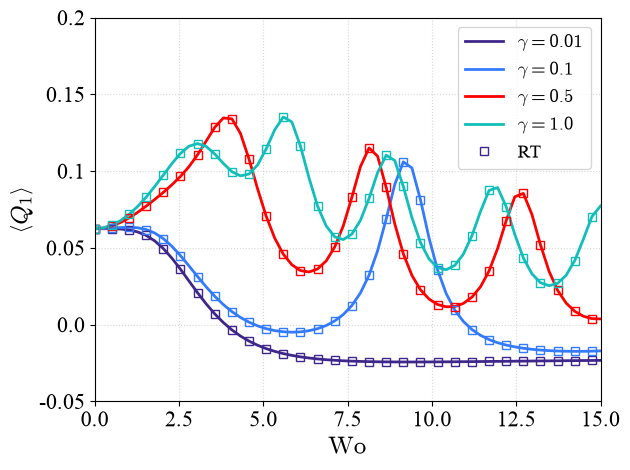

In [23]:
fig, ax = plt.subplots(tight_layout=True)
ax.set_xlabel('$\mathrm{Wo}$')
ax.set_xlim(0, 15)
ax.set_ylabel(r'$\left\langle Q_1 \right\rangle$')
ax.set_ylim(-0.05, 0.2)
#ax.set_aspect('equal', 'box')
ax.grid(alpha=0.5, linestyle='dotted')

ax.plot(Wo_vals, Q1_ODE_1, color=(62/255, 38/255, 138/255), linewidth=2,
        label=fr'$\gamma={Gm_vals[0]}$')
ax.plot(Wo_vals, Q1_ODE_2, color=(51/255, 122/255, 253/255), linewidth=2,
        label=fr'$\gamma={Gm_vals[1]}$')
ax.plot(Wo_vals, Q1_ODE_3, color='red', linewidth=2,
        label=fr'$\gamma={Gm_vals[2]}$')
ax.plot(Wo_vals, Q1_ODE_4, color=(18/255, 190/255, 185/255), linewidth=2,
        label=fr'$\gamma={Gm_vals[3]}$')
# skip some values for RT to avoid overplotting
ax.plot(Wo_vals[::2], Q1_RT_1[::2], label='RT',
        color=(62/255, 38/255, 138/255), linestyle='', marker='s', fillstyle='none')
ax.plot(Wo_vals[::2], Q1_RT_2[::2],
        color=(51/255, 122/255, 253/255), linestyle='', marker='s', fillstyle='none')
ax.plot(Wo_vals[::2], Q1_RT_3[::2],
        color='red', linestyle='', marker='s', fillstyle='none')
ax.plot(Wo_vals[::2], Q1_RT_4[::2],
        color=(18/255, 190/255, 185/255), linestyle='', marker='s', fillstyle='none')

ax.legend()

# font hack for tick labels when using LaTeX fonts
xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([str(round(x,4)) for x in xticks])

yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([str(round(y,4)) for y in yticks])

plt.show()

#fig.savefig('Q1_vs_Wo_EHD_RT.pdf')

## Factorized form

For any $\delta$, the RT result factorizes into a function of $\kappa$ times a function that does not depend on $\gamma$ (see "Checks on claims made in the paper"):
\begin{align*}
    \langle Q_1 \rangle &= \mathrm{Re}\big[ I_1(\kappa) F(Wo,\delta,\mathscr{T}) \big],\\
    I_1 &:= \int_0^1 P_{0,a} \left(\frac{dP_{0,a}}{dZ}\right)^* dZ.
\end{align*}
For pressure control, $I_1$ has a closed form; writing $\kappa = \kappa_r + i\kappa_i$,
$$
    I_1 = -\frac{1}{2} + \frac{i}{2}\, \frac{(\kappa_i/\kappa_r)\sinh^2 \kappa_r - (\kappa_r/\kappa_i)\sin^2 \kappa_i}{\sinh^2 \kappa_r + \sin^2 \kappa_i}.
$$
In the shallow limit, $F$ is
\begin{align*}
    F(Wo,0,\mathscr{T}) &= (1+\mathscr{T}) \Bigg\{ \underbrace{\frac{g'(1)^*}{4}}_{\text{slip}} \\
    &\phantom{=} \underbrace{- \frac{i\, Wo^2}{2 \mathfrak{f}_0(Wo)} \left[ 2\int_0^1 |g|^2 \hat{V}_Z \, dY + \int_0^1 g^* h \, \frac{d\hat{V}_Z}{dY} \, dY \right]}_{\text{advective}} \Bigg\},
\end{align*}
where $g(Y) = \frac{1}{i Wo^2}\left[1 - \frac{\cos(i^{3/2}(1-2Y)Wo/2)}{\cos(i^{3/2}Wo/2)}\right]$ is the Womersley profile, $h(Y) = \int_0^Y g \, dY'$, and $g'(1) = i^{1/2}\tan(i^{3/2}Wo/2)/Wo$.

In [24]:
def zint_closed(kappa):
    """I1 = int_0^1 P0a conj(dP0a/dZ) dZ for P0a = sinh(kappa (1-Z))/sinh(kappa)."""
    kappa_r, kappa_i = kappa.real, kappa.imag
    return -0.5 + 0.5j*((kappa_i/kappa_r)*np.sinh(kappa_r)**2 - (kappa_r/kappa_i)*np.sin(kappa_i)**2) \
                /(np.sinh(kappa_r)**2 + np.sin(kappa_i)**2)

def F_shallow(Wo, Tt=0.0, N=20001):
    """Slip and advective parts of F(Wo, 0, T), including the factor 1 + T, and f0(Wo)."""
    Y = np.linspace(0, 1, N)
    k = 1j**1.5*Wo/2
    g = 1/(1j*Wo**2)*(1 - np.cos(k*(1 - 2*Y))/np.cos(k))
    h = 1/(1j*Wo**2)*(Y - (np.sin(k) - np.sin(k*(1 - 2*Y)))/(2*k*np.cos(k)))   # int_0^Y g
    f0 = 1/(1j*Wo**2)*(1 - np.tan(k)/k)
    VzHat = Y*(1 - Y)/2
    dVzHat = (1 - 2*Y)/2
    gp1 = 1j**0.5*np.tan(k)/Wo     # g'(1)
    F_slip = (1 + Tt)*np.conj(gp1)/4
    F_adv = -(1 + Tt)*1j*Wo**2/(2*f0)*(2*trapezoid(abs(g)**2*VzHat, Y) + trapezoid(np.conj(g)*h*dVzHat, Y))
    return F_slip, F_adv, f0

def Q1_shallow(Wo, Gm, Tt=0.0):
    """<Q1>, slip part, advective part, in the shallow limit."""
    F_slip, F_adv, f0 = F_shallow(Wo, Tt)
    I1z = zint_closed(np.sqrt(1j*(1 + Tt)*Gm/f0))
    slip = np.real(I1z*F_slip)
    adv = np.real(I1z*F_adv)
    return slip + adv, slip, adv

Check against the symbolic RT calculation above, and the low-frequency limit $\langle Q_1 \rangle \to (1+\mathscr{T})/16$ as $Wo \to 0$.

In [25]:
# the factorized form against the symbolic RT calculation, at a few points: Wo, gamma, T
points = [[3.0, 0.5, 0.0],
          [9.2, 0.1, 0.0],
          [12.0, 1.0, 0.0],
          [6.0, 1.0, 0.3],
          [0.3, 0.01, 0.0]]

for my_Wo, my_Gm, my_Tt in points:
    Q1, slip, adv = Q1_shallow(my_Wo, my_Gm, my_Tt)
    Q1_sympy = quad(I1_integrand_num, 0, 1, args=(my_Wo, my_Gm, my_Tt))[0] \
               + dblquad(RT_integrand_num, 0, 1, 0, 1, args=(my_Wo, my_Gm, my_Tt))[0]
    print(f'Wo = {my_Wo}, gamma = {my_Gm}, T = {my_Tt}:  <Q1> = {Q1:.6f} (symbolic RT {Q1_sympy:.6f}),'
          f'  slip = {slip:.6f}, advective = {adv:.6f}')
    assert abs(Q1 - Q1_sympy) < 1e-6

# low-frequency limit
for my_Tt in (0.0, 0.3):
    print(f'Wo = 0.001, T = {my_Tt}:  <Q1> = {Q1_shallow(1e-3, 0.1, my_Tt)[0]:.6f}, (1+T)/16 = {(1 + my_Tt)/16:.6f}')
    assert abs(Q1_shallow(1e-3, 0.1, my_Tt)[0] - (1 + my_Tt)/16) < 1e-6

Wo = 3.0, gamma = 0.5, T = 0.0:  <Q1> = 0.108969 (symbolic RT 0.108969),  slip = 0.089340, advective = 0.019629
Wo = 9.2, gamma = 0.1, T = 0.0:  <Q1> = 0.106908 (symbolic RT 0.106908),  slip = 0.115860, advective = -0.008952


Wo = 12.0, gamma = 1.0, T = 0.0:  <Q1> = 0.087782 (symbolic RT 0.087782),  slip = 0.116194, advective = -0.028412
Wo = 6.0, gamma = 1.0, T = 0.3:  <Q1> = 0.112673 (symbolic RT 0.112673),  slip = 0.107846, advective = 0.004827
Wo = 0.3, gamma = 0.01, T = 0.0:  <Q1> = 0.062509 (symbolic RT 0.062509),  slip = 0.062505, advective = 0.000004
Wo = 0.001, T = 0.0:  <Q1> = 0.062500, (1+T)/16 = 0.062500
Wo = 0.001, T = 0.3:  <Q1> = 0.081250, (1+T)/16 = 0.081250


# Arbitrary aspect ratio $\delta = h_0/w$

For $\delta = O(1)$, the RT result reads
\begin{align*}
    \langle Q_1 \rangle &= \int_0^1 \int_{-1/2}^{+1/2} \left.\frac{\partial \hat{V}_Z}{\partial Y}\right|_{Y=1} \left\langle \left.\frac{\partial V_{Z,0}}{\partial Y}\right|_{Y=1} U_{Y,0} \right\rangle dX \, dZ \\
    &\phantom{=} - \frac{Wo^2}{\gamma} \int_0^1 \int_0^1 \int_{-1/2}^{+1/2} \Bigg[ \delta \left\langle V_{X,0} \frac{\partial V_{Z,0}}{\partial X} \right\rangle + \left\langle V_{Y,0} \frac{\partial V_{Z,0}}{\partial Y} \right\rangle \\
    &\phantom{=} \qquad\qquad + \left\langle V_{Z,0} \frac{\partial V_{Z,0}}{\partial Z} \right\rangle \Bigg] \hat{V}_Z \, dX \, dY \, dZ.
\end{align*}

## Closed-form ingredients

The hat flow and the primary axial flow $V_{Z,0,a} = G(X,Y)\,(-dP_{0,a}/dZ)$ are sums over odd $n$, with $\lambda_n^2 = n^2\pi^2 + i Wo^2$ (the paper sums over $n = 1, 2, 3, \dots$ and writes $2n-1$ for the odd $n$ here; the series are the same):
\begin{align*}
    \hat{V}_Z &= \frac{Y(1-Y)}{2} - \frac{4}{\pi^3} \sum_n \frac{1}{n^3} \frac{\cosh(n\pi X/\delta)}{\cosh(n\pi/2\delta)} \sin(n\pi Y),\\
    \left.\frac{\partial \hat{V}_Z}{\partial Y}\right|_{Y=1} &= -\frac{1}{2} + \frac{4}{\pi^2} \sum_n \frac{1}{n^2} \frac{\cosh(n\pi X/\delta)}{\cosh(n\pi/2\delta)},\\
    G &= \sum_n \frac{4 \sin(n\pi Y)}{n\pi\lambda_n^2} \left[1 - \frac{\cosh(\lambda_n X/\delta)}{\cosh(\lambda_n/2\delta)}\right],\\
    \left.\frac{\partial G}{\partial Y}\right|_{Y=1} &= -\sum_n \frac{4}{\lambda_n^2} \left[1 - \frac{\cosh(\lambda_n X/\delta)}{\cosh(\lambda_n/2\delta)}\right].
\end{align*}
The flow rate of the primary flow, the pressure parameter $\kappa$, and the deformation are
\begin{align*}
    \mathfrak{f}_0(Wo,\delta) &= \sum_n \frac{8}{n^2\pi^2\lambda_n^2}\left[1 - \frac{2\delta}{\lambda_n}\tanh\frac{\lambda_n}{2\delta}\right],\\
    \kappa &= \sqrt{\frac{i(1+\mathscr{T})\gamma}{\mathfrak{f}_0(Wo,\delta)}},\\
    U_{Y,0,a} &= \mathcal{U}(X) P_{0,a}(Z).
\end{align*}
Then, the slip term is
$$
    \mathrm{slip} = \frac{1}{2}\mathrm{Re}\left[ -I_1^* \int_{-1/2}^{+1/2} \left.\frac{\partial \hat{V}_Z}{\partial Y}\right|_{Y=1} \left.\frac{\partial G}{\partial Y}\right|_{Y=1} \mathcal{U}(X) \, dX \right].
$$
The wall-shear series converge slowly: after $n_\mathrm{max}$ terms, the error is of order $1/n_\mathrm{max}$. For large $n$, $\lambda_n \approx n\pi$ and, away from the side walls, the $\cosh$ ratio is negligible, so each term of $\partial G/\partial Y|_{Y=1}$ is close to $-4/(n\pi)^2$. We therefore add the sum of the omitted terms, $-\frac{4}{\pi^2}\sum_{n>n_\mathrm{max}} n^{-2} \approx -\frac{2}{\pi^2 n_\mathrm{max}}$, in closed form; near the side walls, where this estimate is poor, the integrand of the slip term vanishes with $\mathcal{U}(X)$.

In [26]:
def ratio(a, X):
    """cosh(a X)/cosh(a/2), written so that it does not overflow for large a."""
    return (np.exp(a*(X - 0.5)) + np.exp(-a*(X + 0.5)))/(1 + np.exp(-a))

def lam(n, Wo):    # n odd here; the paper's lambda_n is lam(2n-1)
    return np.sqrt((n*np.pi)**2 + 1j*Wo**2)

def VzHat_series(X, Y, delta, nmax=399):
    VzHat = Y*(1 - Y)/2
    for n in range(1, nmax + 1, 2):
        VzHat = VzHat - 4/(n*np.pi)**3*ratio(n*np.pi/delta, X)*np.sin(n*np.pi*Y)
    return VzHat

def VzHatY_wall(X, delta, nmax=2001):
    VzHatY = -0.5
    for n in range(1, nmax + 1, 2):    # odd n here is the paper's 2n-1
        VzHatY = VzHatY + 4/(n*np.pi)**2*ratio(n*np.pi/delta, X)
    return VzHatY

def G_series(X, Y, Wo, delta, nmax=399):
    G = 0
    for n in range(1, nmax + 1, 2):    # odd n here is the paper's 2n-1
        G = G + 4*np.sin(n*np.pi*Y)/(n*np.pi*lam(n, Wo)**2)*(1 - ratio(lam(n, Wo)/delta, X))
    return G

def GY_wall(X, Wo, delta, nmax=2001):
    GY = -2/(np.pi**2*nmax)    # the terms with n > nmax (see above)
    for n in range(1, nmax + 1, 2):    # odd n here is the paper's 2n-1
        GY = GY - 4/lam(n, Wo)**2*(1 - ratio(lam(n, Wo)/delta, X))
    return GY

def f0_series(Wo, delta, nmax=20001):
    n = np.arange(1, nmax + 1, 2)    # odd n here is the paper's 2n-1
    return np.sum(8/(n**2*np.pi**2*lam(n, Wo)**2)*(1 - (2*delta/lam(n, Wo))*np.tanh(lam(n, Wo)/(2*delta))))

def Ucal(X, Tt):
    """Top-wall deformation per unit pressure; its integral over X is 1 + T."""
    return 30*(0.25 - X**2)*((0.25 - X**2) + Tt/5)

def kappa_delta(Wo, Gm, delta, Tt=0.0):
    return np.sqrt(1j*(1 + Tt)*Gm/f0_series(Wo, delta))

def slip_delta(Wo, Gm, delta, Tt=0.0):
    X = np.linspace(-0.5, 0.5, 801)
    I1z = zint_closed(kappa_delta(Wo, Gm, delta, Tt))
    return 0.5*np.real(-np.conj(I1z)*trapezoid(VzHatY_wall(X, delta)*GY_wall(X, Wo, delta)*Ucal(X, Tt), X))

### Checks on the closed-form pieces

1. At $Wo = 0$, $\mathfrak{f}_0$ is the flow rate of the hat problem, 
$$
    \hat{Q} = \tfrac{1}{12}[1-\chi(\delta)],\quad 
    \chi(\delta) = \frac{192}{\pi^5}\sum_n \frac{1}{n^5}\,\delta\tanh(n\pi/2\delta).
$$
2. The reciprocal theorem applied to the hat problem and the primary axial flow: 
$$
    i Wo^2 \iint G \hat{V}_Z \, dX dY = \hat{Q} - \mathfrak{f}_0(Wo,\delta).
$$
3. The other side of the same identity, along the channel:
$$
    \hat{Q} - Q_{0,a}(0) + i\gamma(1+\mathscr{T})\int_0^1 (1-Z)\, P_{0,a}\, dZ = \hat{Q} - \mathfrak{f}_0(Wo,\delta),\quad Q_{0,a}(0) = \mathfrak{f}_0\,\kappa\coth\kappa.
$$

In [27]:
# 1. f0(0, delta) = (1 - chi)/12
def Qhat_series(delta, nmax=20001):
    n = np.arange(1, nmax + 1, 2)
    chi = 192/np.pi**5*np.sum(delta*np.tanh(n*np.pi/(2*delta))/n**5)
    return (1 - chi)/12

for delta in (0.1, 0.5, 1.0, 2.0):
    print(f'delta = {delta}:  f0(0, delta) = {f0_series(0, delta).real:.8f},  (1 - chi)/12 = {Qhat_series(delta):.8f}')
    assert abs(f0_series(0, delta) - Qhat_series(delta)) < 1e-12

delta = 0.1:  f0(0, delta) = 0.07808126,  (1 - chi)/12 = 0.07808126
delta = 0.5:  f0(0, delta) = 0.05717042,  (1 - chi)/12 = 0.05717042
delta = 1.0:  f0(0, delta) = 0.03514425,  (1 - chi)/12 = 0.03514425
delta = 2.0:  f0(0, delta) = 0.01429260,  (1 - chi)/12 = 0.01429260


In [28]:
# 2. reciprocal theorem for the hat and axial-flow problems, with the double integral by Gauss-Legendre quadrature
xg, wg = np.polynomial.legendre.leggauss(200)
X, Y = np.meshgrid(xg/2, (xg + 1)/2, indexing='ij')    # X in [-1/2, 1/2], Y in [0, 1]
w = np.outer(wg/2, wg/2)

for my_Wo, delta in ((3.0, 0.5), (8.0, 0.5), (3.0, 1.0), (8.0, 0.25)):
    lhs = 1j*my_Wo**2*np.sum(w*G_series(X, Y, my_Wo, delta, nmax=1999)*VzHat_series(X, Y, delta, nmax=1999))
    rhs = Qhat_series(delta) - f0_series(my_Wo, delta)
    print(f'Wo = {my_Wo}, delta = {delta}:  i Wo^2 int G VzHat = {lhs:.8f},  Qhat - f0 = {rhs:.8f}')
    assert abs(lhs - rhs) < 1e-6

Wo = 3.0, delta = 0.5:  i Wo^2 int G VzHat = 0.01867879+0.02609433j,  Qhat - f0 = 0.01867879+0.02609433j


Wo = 8.0, delta = 0.5:  i Wo^2 int G VzHat = 0.05364805+0.01150179j,  Qhat - f0 = 0.05364805+0.01150179j


Wo = 3.0, delta = 1.0:  i Wo^2 int G VzHat = 0.00574123+0.01270953j,  Qhat - f0 = 0.00574123+0.01270953j


Wo = 8.0, delta = 0.25:  i Wo^2 int G VzHat = 0.06706318+0.01219576j,  Qhat - f0 = 0.06706318+0.01219576j


In [29]:
# 3. the other side of the same identity: Qhat - Q0a(0) + i gamma (1+T) int_0^1 (1-Z) P0a dZ = Qhat - f0
points = [[3.0, 0.5, 0.5, 0.0],
          [8.0, 1.0, 0.25, 0.3],
          [12.0, 0.1, 1.0, 0.0]]

for my_Wo, my_Gm, delta, my_Tt in points:
    f0_val = f0_series(my_Wo, delta)
    kappa_val = kappa_delta(my_Wo, my_Gm, delta, my_Tt)
    Q0a_0 = f0_val*kappa_val/np.tanh(kappa_val)    # flow rate at Z = 0
    def integrand(Z):
        return (1 - Z)*np.sinh(kappa_val*(1 - Z))/np.sinh(kappa_val)
    lhs = Qhat_series(delta) - Q0a_0 + 1j*my_Gm*(1 + my_Tt)*quad(integrand, 0, 1, complex_func=True)[0]
    rhs = Qhat_series(delta) - f0_val
    print(f'Wo = {my_Wo}, gamma = {my_Gm}, delta = {delta}, T = {my_Tt}:  |lhs - (Qhat - f0)| = {abs(lhs - rhs):.1e}')
    assert abs(lhs - rhs) < 1e-8

Wo = 3.0, gamma = 0.5, delta = 0.5, T = 0.0:  |lhs - (Qhat - f0)| = 2.5e-17
Wo = 8.0, gamma = 1.0, delta = 0.25, T = 0.3:  |lhs - (Qhat - f0)| = 7.8e-17
Wo = 12.0, gamma = 0.1, delta = 1.0, T = 0.0:  |lhs - (Qhat - f0)| = 5.2e-18


## Cross-flow

The advective term needs the primary cross-flow $(V_{X,0}, V_{Y,0})$, which has no closed form for $\delta = O(1)$. We write
$\{V_{X,0,a}, V_{Y,0,a}\} = i\gamma P_{0,a}(Z)\,\{W_X, W_Y\}(X,Y)$, where $\boldsymbol{W}$ does not depend on $\gamma$ or $Z$ and satisfies
\begin{align*}
    i Wo^2 W_X &= -\delta \frac{\partial \Pi}{\partial X} + \nabla_\delta^2 W_X,\\
    i Wo^2 W_Y &= -\frac{\partial \Pi}{\partial Y} + \nabla_\delta^2 W_Y,\\
    \delta\frac{\partial W_X}{\partial X} + \frac{\partial W_Y}{\partial Y} &= \frac{(1+\mathscr{T})\, G}{\mathfrak{f}_0},
\end{align*}
with $\nabla_\delta^2 = \partial^2/\partial Y^2 + \delta^2\partial^2/\partial X^2$, $\boldsymbol{W} = \boldsymbol{0}$ on the rigid walls $Y = 0$ and $X = \pm\tfrac{1}{2}$, and $W_X = 0$, $W_Y = \mathcal{U}(X)$ on the top wall $Y = 1$.
In the coordinates $x = X/\delta \in [-1/(2\delta), +1/(2\delta)]$ and $y = Y$, this is an ordinary unsteady Stokes problem. We solve it with Taylor&ndash;Hood finite elements ($\mathbb{Q}_2$ velocity, $\mathbb{Q}_1$ pressure) on a quadrilateral mesh that is refined toward all four walls, to resolve the Stokes layers. The pressure is fixed at one corner, and the mass source is rescaled slightly so that it exactly balances the flux through the deforming top wall; then the discrete continuity equation holds everywhere, including at the corner where the pressure is fixed.

Then, the advective term is $-(Wo^2/\gamma) A$, with
\begin{align*}
    A &= \tfrac{1}{2}\mathrm{Re}\left[ -i\gamma I_1 T_{12} + (\kappa^2)^* I_1^* T_3 \right],\\
    T_{12} &= \iint \left(\delta W_X \frac{\partial G^*}{\partial X} + W_Y \frac{\partial G^*}{\partial Y}\right) \hat{V}_Z \, dX dY,\\
    T_3 &= \iint |G|^2 \hat{V}_Z \, dX dY.
\end{align*}
Integrating by parts gives another formula for $A$, which we use as an independent check on the cross-flow:
\begin{align*}
    A &= \tfrac{1}{2}\left(|P_{0,a}'(1)|^2 - |P_{0,a}'(0)|^2\right) T_3 - \tfrac{1}{2}\mathrm{Re}\left[ i\gamma I_1^* \, T_{12}^c \right],\\
    T_{12}^c &= \iint G \left(\delta W_X^* \frac{\partial \hat{V}_Z}{\partial X} + W_Y^* \frac{\partial \hat{V}_Z}{\partial Y}\right) dX dY.
\end{align*}

In complex mode, UFL's `inner(a, b)` is $a b^*$, which is the product we need in $T_{12}$, $T_3$, and $T_{12}^c$.

In [30]:
from mpi4py import MPI
import ufl
import basix.ufl
from dolfinx import mesh, fem, default_scalar_type
from dolfinx.fem.petsc import LinearProblem

assert np.issubdtype(default_scalar_type, np.complexfloating), 'this section needs the complex build of DOLFINx'

# direct (LU) solver for the linear systems
LU = {'ksp_type': 'preonly', 'pc_type': 'lu', 'pc_factor_mat_solver_type': 'mumps'}

def integrate(form):
    return fem.assemble_scalar(fem.form(form))

def crossflow_mesh(delta, ny):
    """Mesh of x in [-1/(2 delta), 1/(2 delta)], y in [0, 1], with ny cells across the depth, refined toward the walls."""
    Lx = 1/delta
    nx = int(ny*(1 + np.log2(max(Lx, 1))))    # more cells across wider channels
    msh = mesh.create_rectangle(MPI.COMM_WORLD, [np.array([-Lx/2, 0]), np.array([Lx/2, 1])], [nx, ny],
                                mesh.CellType.quadrilateral)
    # move the vertices toward the walls (tanh stretching); the walls themselves stay where they are
    bx, by = 1.5 + 0.5*np.log(max(Lx, 1)), 1.5
    x = msh.geometry.x
    x[:, 0] = Lx/2*np.tanh(bx*x[:, 0]/(Lx/2))/np.tanh(bx)
    x[:, 1] = 0.5*(1 + np.tanh(by*(2*x[:, 1] - 1))/np.tanh(by))
    return msh

In [31]:
def crossflow_solve(Wo, delta, Tt=0.0, ny=32, return_field=False):
    """Solve for the cross-flow W; return the integrals T12, T3 and T12c,
    or, with return_field=True, the flow W itself and what is needed to check it (for the appendix figures)."""
    msh = crossflow_mesh(delta, ny)
    Lx = 1/delta
    dx = ufl.Measure('dx', domain=msh, metadata={'quadrature_degree': 10})

    # G and VzHat from their series (X = delta x), as degree-4 finite element functions
    V4 = fem.functionspace(msh, ('Lagrange', 4))
    G, VzHat = fem.Function(V4), fem.Function(V4)
    G.interpolate(lambda p: G_series(delta*p[0], p[1], Wo, delta))
    VzHat.interpolate(lambda p: VzHat_series(delta*p[0], p[1], delta) + 0j)

    # Taylor-Hood elements
    cell = msh.basix_cell()
    W = fem.functionspace(msh, basix.ufl.mixed_element([basix.ufl.element('Lagrange', cell, 2, shape=(2,)),
                                                        basix.ufl.element('Lagrange', cell, 1)]))
    W0, _ = W.sub(0).collapse()
    W1, _ = W.sub(1).collapse()

    # boundary conditions: W = 0 on the rigid walls, W = (0, Ucal) on the top wall, and pressure = 0 at one corner
    def top(p):        # the deforming top wall, y = 1
        return np.isclose(p[1], 1)
    def rigid(p):      # the bottom wall, y = 0, and the side walls, x = -Lx/2 and Lx/2
        return np.isclose(p[1], 0) | np.isclose(abs(p[0]), Lx/2)
    def corner(p):     # the bottom-left corner, where the pressure is fixed
        return np.isclose(p[0], -Lx/2) & np.isclose(p[1], 0)
    w_top, w_zero, p_zero = fem.Function(W0), fem.Function(W0), fem.Function(W1)
    w_top.interpolate(lambda p: np.vstack([0*p[0], Ucal(delta*p[0], Tt)]) + 0j)
    bcs = [fem.dirichletbc(w_zero, fem.locate_dofs_geometrical((W.sub(0), W0), rigid), W.sub(0)),
           fem.dirichletbc(w_top, fem.locate_dofs_geometrical((W.sub(0), W0), top), W.sub(0)),
           fem.dirichletbc(p_zero, fem.locate_dofs_geometrical((W.sub(1), W1), corner), W.sub(1))]

    # mass source (1+T) G/f0, rescaled to balance the flux through the top wall exactly
    top_facets = mesh.locate_entities_boundary(msh, 1, top)
    ds_top = ufl.Measure('ds', domain=msh, subdomain_data=mesh.meshtags(msh, 1, top_facets, 1))(1)
    S = G*integrate(w_top[1]*ds_top)/integrate(G*dx)

    # weak form; i Wo^2 is a Constant, so that the form is compiled only once for all Wo
    (w, p), (z, q) = ufl.TrialFunctions(W), ufl.TestFunctions(W)
    iWo2 = fem.Constant(msh, default_scalar_type(1j*Wo**2))
    a = (iWo2*ufl.inner(w, z) + ufl.inner(ufl.grad(w), ufl.grad(z))
         - ufl.inner(p, ufl.div(z)) - ufl.inner(ufl.div(w), q))*dx
    L = -ufl.inner(S, q)*dx
    Wsol = LinearProblem(a, L, bcs=bcs, petsc_options=LU, petsc_options_prefix='crossflow_').solve().sub(0)

    # integrals over the cross-section: dX dY = delta dx dy and delta d/dX = d/dx
    T12 = delta*integrate(ufl.inner(Wsol, ufl.grad(G))*VzHat*dx)
    T3 = delta*integrate(ufl.inner(G, G)*VzHat*dx).real
    T12c = delta*integrate(G*ufl.inner(ufl.grad(VzHat), Wsol)*dx)
    if return_field:
        return dict(W=Wsol.collapse(), S=S, dx=dx, ds_top=ds_top, pressure_space=W1, rigid=rigid)
    return T12, T3, T12c

In [32]:
def Q1_delta(Wo, Gm, delta, Tt=0.0, ny=32, integrals=None):
    """<Q1>, its slip and advective parts, and the advective part from the conservative form.
    The integrals from crossflow_solve can be passed in to reuse them for another gamma."""
    if integrals is None:
        integrals = crossflow_solve(Wo, delta, Tt, ny)
    T12, T3, T12c = integrals
    kappa = kappa_delta(Wo, Gm, delta, Tt)
    I1z = zint_closed(kappa)
    A = 0.5*np.real(-1j*Gm*I1z*T12 + np.conj(kappa**2)*np.conj(I1z)*T3)
    # conservative form, with |dP0a/dZ|^2 at Z = 1 and Z = 0
    dP1sq, dP0sq = abs(kappa/np.sinh(kappa))**2, abs(kappa/np.tanh(kappa))**2
    A_cons = 0.5*(dP1sq - dP0sq)*T3 - 0.5*np.real(1j*Gm*np.conj(I1z)*T12c)
    slip = slip_delta(Wo, Gm, delta, Tt)
    return dict(Q1=slip - Wo**2/Gm*A, slip=slip, adv=-Wo**2/Gm*A, adv_cons=-Wo**2/Gm*A_cons)

## Checks on the cross-flow

A test of the solver against a manufactured solution is in the appendix.

### Mesh resolution

Check mesh convergence at $Wo = 8$, $\gamma = 1$, $\delta = 0.5$ (with `ny` cells across the depth), and compare the two forms of the advective term.

In [33]:
def mesh_convergence():
    ny_vals = np.array([16, 24, 32, 48, 64])
    Q1 = np.zeros(ny_vals.size)
    adv = np.zeros(ny_vals.size)
    adv_cons = np.zeros(ny_vals.size)
    for i, ny in enumerate(ny_vals):
        r = Q1_delta(8.0, 1.0, 0.5, ny=ny)
        Q1[i], adv[i], adv_cons[i] = r['Q1'], r['adv'], r['adv_cons']
    return dict(ny=ny_vals, Q1=Q1, adv=adv, adv_cons=adv_cons)

# saved result: delete the file (or set recompute = True) to recompute
conv = load_or_compute(f'{cache_dir}/mesh_convergence_3D.npz', mesh_convergence)
for i in range(conv['ny'].size):
    print(f"ny = {conv['ny'][i]}:  <Q1> = {conv['Q1'][i]:.8f},  advective = {conv['adv'][i]:.8f},"
          f"  conservative form = {conv['adv_cons'][i]:.8f}")
assert abs(conv['Q1'][2] - conv['Q1'][-1]) < 1e-7    # ny = 32 is converged

loaded cache_3D/mesh_convergence_3D.npz
ny = 16:  <Q1> = 0.07878938,  advective = 0.00850127,  conservative form = 0.00850256
ny = 24:  <Q1> = 0.07878980,  advective = 0.00850169,  conservative form = 0.00850198
ny = 32:  <Q1> = 0.07878991,  advective = 0.00850180,  conservative form = 0.00850191
ny = 48:  <Q1> = 0.07878993,  advective = 0.00850183,  conservative form = 0.00850185
ny = 64:  <Q1> = 0.07878994,  advective = 0.00850183,  conservative form = 0.00850184


The Stokes layers have thickness $\sim\sqrt{2}/Wo$. Check that `ny = 32` resolves them over the range of $Wo$ used below, for all $\gamma$, by comparing with `ny = 64`.

In [34]:
def stokes_layer_check():
    deltas, Wos, Gms = [0.25, 0.5, 1.0], [1e-3, 15.0], [0.01, 0.1, 0.5, 1.0]
    diff = np.zeros((len(deltas), len(Wos)))
    for i, delta in enumerate(deltas):
        for k, my_Wo in enumerate(Wos):
            integrals_32 = crossflow_solve(my_Wo, delta, ny=32)
            integrals_64 = crossflow_solve(my_Wo, delta, ny=64)
            for my_Gm in Gms:
                Q1_32 = Q1_delta(my_Wo, my_Gm, delta, integrals=integrals_32)['Q1']
                Q1_64 = Q1_delta(my_Wo, my_Gm, delta, integrals=integrals_64)['Q1']
                diff[i, k] = max(diff[i, k], abs(Q1_32 - Q1_64))
    return dict(delta=deltas, Wo=Wos, diff=diff)

# saved result: delete the file (or set recompute = True) to recompute
sl = load_or_compute(f'{cache_dir}/stokes_layer_check_3D.npz', stokes_layer_check)
for i, delta in enumerate(sl['delta']):
    for k, my_Wo in enumerate(sl['Wo']):
        print(f'delta = {delta}, Wo = {my_Wo}:  max over gamma of |<Q1>(ny=32) - <Q1>(ny=64)| = {sl["diff"][i, k]:.1e}')
assert np.all(sl['diff'] < 1e-6)

loaded cache_3D/stokes_layer_check_3D.npz
delta = 0.25, Wo = 0.001:  max over gamma of |<Q1>(ny=32) - <Q1>(ny=64)| = 8.9e-16
delta = 0.25, Wo = 15.0:  max over gamma of |<Q1>(ny=32) - <Q1>(ny=64)| = 3.4e-08
delta = 0.5, Wo = 0.001:  max over gamma of |<Q1>(ny=32) - <Q1>(ny=64)| = 4.8e-16
delta = 0.5, Wo = 15.0:  max over gamma of |<Q1>(ny=32) - <Q1>(ny=64)| = 4.4e-08
delta = 1.0, Wo = 0.001:  max over gamma of |<Q1>(ny=32) - <Q1>(ny=64)| = 3.6e-16
delta = 1.0, Wo = 15.0:  max over gamma of |<Q1>(ny=32) - <Q1>(ny=64)| = 6.9e-08


### Approach to the shallow limit

Check the approach to the shallow limit at $Wo = 3$, $\gamma = 0.5$; the difference should be $O(\delta)$.

In [35]:
Q1_lim = Q1_shallow(3.0, 0.5)[0]
print(f'shallow limit:  <Q1> = {Q1_lim:.6f}')
for delta in (0.2, 0.1, 0.05, 0.02, 0.01):
    Q1 = Q1_delta(3.0, 0.5, delta)['Q1']
    print(f'delta = {delta}:  <Q1> = {Q1:.6f},  (<Q1> - shallow)/delta = {(Q1 - Q1_lim)/delta:.4f}')
assert abs(Q1 - Q1_lim) < 2e-4

shallow limit:  <Q1> = 0.108969


delta = 0.2:  <Q1> = 0.108313,  (<Q1> - shallow)/delta = -0.0033


delta = 0.1:  <Q1> = 0.109990,  (<Q1> - shallow)/delta = 0.0102


delta = 0.05:  <Q1> = 0.109726,  (<Q1> - shallow)/delta = 0.0151


delta = 0.02:  <Q1> = 0.109314,  (<Q1> - shallow)/delta = 0.0172


delta = 0.01:  <Q1> = 0.109147,  (<Q1> - shallow)/delta = 0.0178


## Streaming flow rate against $Wo$

$\langle Q_1 \rangle$ against $Wo$ in the shallow limit and for $\delta = 0.25, 0.5, 1$, one panel per $\gamma$. The cross-flow does not depend on $\gamma$, so one solve per $(Wo,\delta)$ serves all the panels.

In [36]:
Wo_vals_d = np.linspace(1e-3, 15, 151)
Gm_vals_d = np.array([0.01, 0.1, 0.5, 1.0])
delta_vals = np.array([0.25, 0.5, 1.0])
Tt_val_d = 0.0

# shallow limit: closed form, so no saved file is needed; a fine grid of Wo, arrays indexed [gamma, Wo]
Wo_vals_sh = np.linspace(1e-3, 15, 601)
Q1_sh = np.zeros((Gm_vals_d.size, Wo_vals_sh.size))
slip_sh = np.zeros((Gm_vals_d.size, Wo_vals_sh.size))
adv_sh = np.zeros((Gm_vals_d.size, Wo_vals_sh.size))
for j, my_Gm in enumerate(Gm_vals_d):
    for k, my_Wo in enumerate(Wo_vals_sh):
        Q1_sh[j, k], slip_sh[j, k], adv_sh[j, k] = Q1_shallow(my_Wo, my_Gm, Tt_val_d)

# arbitrary delta: one cross-flow solve per Wo serves all gamma; arrays indexed [gamma, Wo]
def compute_Q1_delta_of_Wo(delta):
    Q1 = np.zeros((Gm_vals_d.size, Wo_vals_d.size))
    slip = np.zeros((Gm_vals_d.size, Wo_vals_d.size))
    adv = np.zeros((Gm_vals_d.size, Wo_vals_d.size))
    for k, my_Wo in enumerate(Wo_vals_d):
        integrals = crossflow_solve(my_Wo, delta, Tt_val_d)
        for j, my_Gm in enumerate(Gm_vals_d):
            r = Q1_delta(my_Wo, my_Gm, delta, Tt_val_d, integrals=integrals)
            Q1[j, k], slip[j, k], adv[j, k] = r['Q1'], r['slip'], r['adv']
    return dict(Wo=Wo_vals_d, gamma=Gm_vals_d, Q1=Q1, slip=slip, adv=adv)

# all delta, arrays indexed [delta, gamma, Wo]
Q1_d = np.zeros((delta_vals.size, Gm_vals_d.size, Wo_vals_d.size))
slip_d = np.zeros((delta_vals.size, Gm_vals_d.size, Wo_vals_d.size))
adv_d = np.zeros((delta_vals.size, Gm_vals_d.size, Wo_vals_d.size))
for i, delta in enumerate(delta_vals):
    # saved result, one file per delta: delete the file (or set recompute = True) to recompute
    data = load_or_compute(f'{cache_dir}/Q1_vs_Wo_delta{delta:g}_3D.npz', lambda: compute_Q1_delta_of_Wo(delta))
    assert np.array_equal(data['Wo'], Wo_vals_d) and np.array_equal(data['gamma'], Gm_vals_d)
    Q1_d[i], slip_d[i], adv_d[i] = data['Q1'], data['slip'], data['adv']


loaded cache_3D/Q1_vs_Wo_delta0.25_3D.npz
loaded cache_3D/Q1_vs_Wo_delta0.5_3D.npz
loaded cache_3D/Q1_vs_Wo_delta1_3D.npz


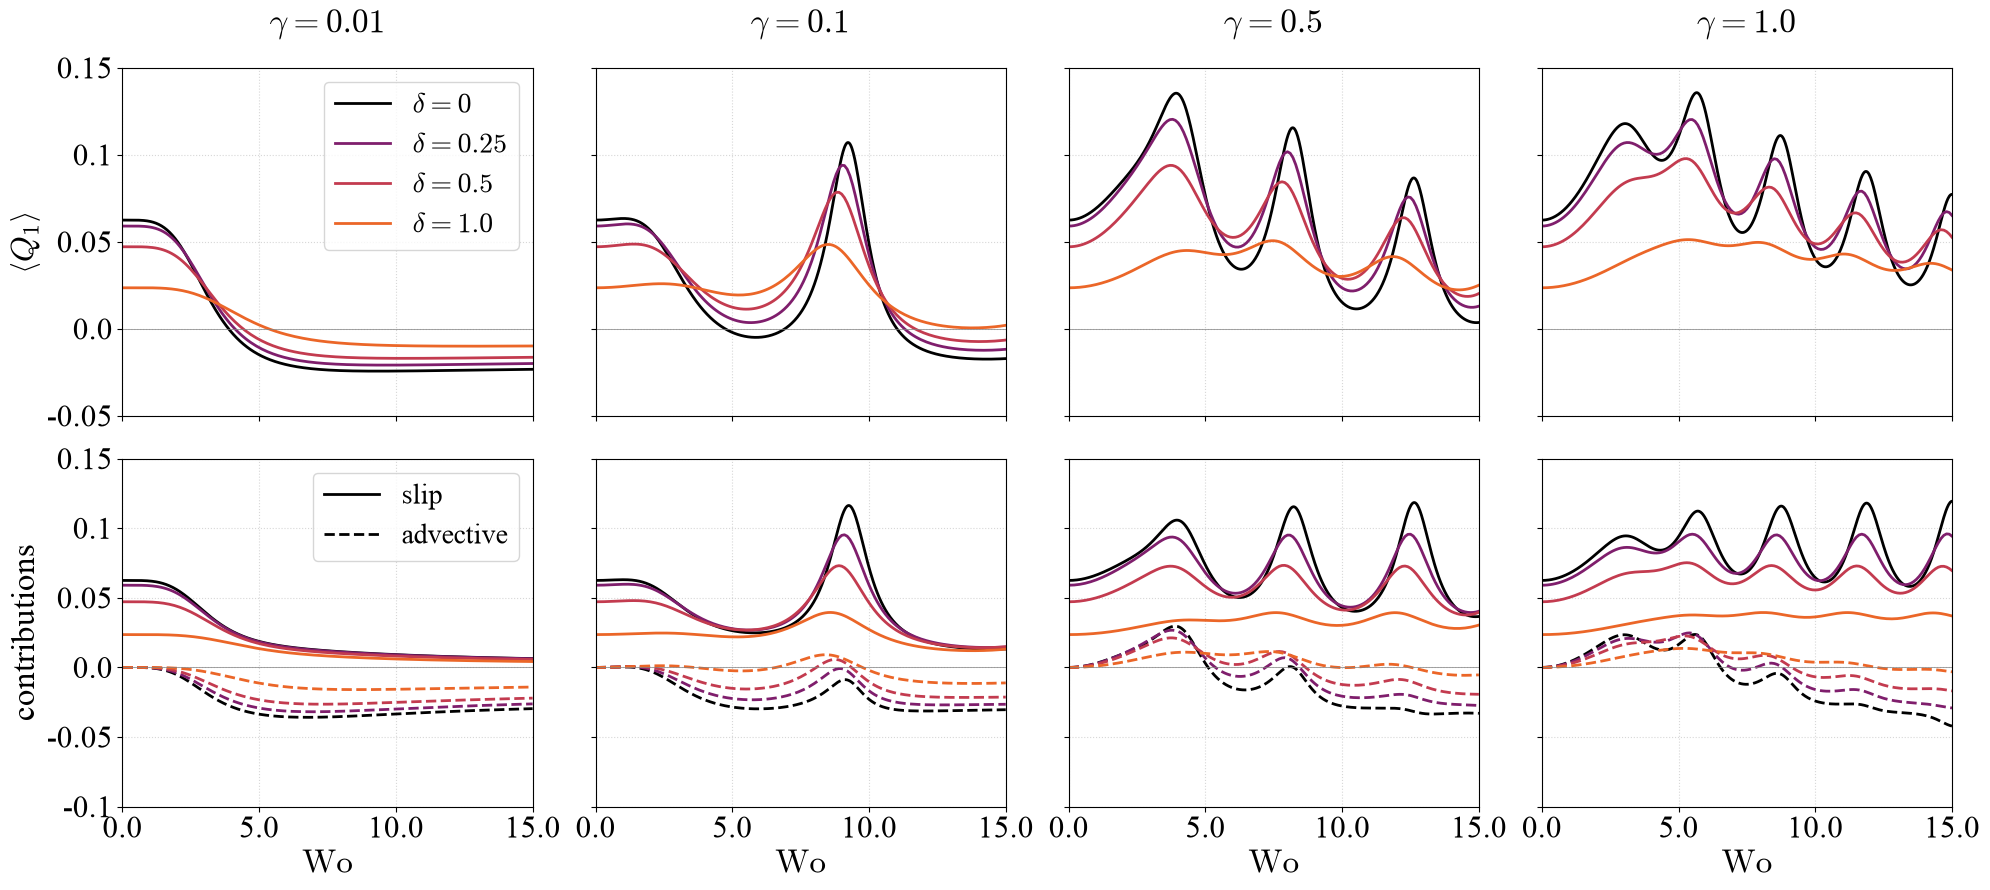

In [37]:
# sequential colors: black for delta -> 0, brighter as delta grows
# (inferno, stopped at 0.66 so that every curve has at least 3:1 contrast on white)
cmap = colormaps['inferno']
delta_colors = [cmap(0.35), cmap(0.52), cmap(0.66)]

# larger fonts than the notebook default, for the 2 x 4 layout
fs = size + 6

fig, axs = plt.subplots(2, Gm_vals_d.size, figsize=(5*Gm_vals_d.size, 9), sharex=True, sharey='row', tight_layout=True)
for j, Gm_c in enumerate(Gm_vals_d):
    ax = axs[0, j]
    ax.set_title(fr'$\gamma={Gm_c}$', fontsize=fs)
    ax.plot(Wo_vals_sh, Q1_sh[j], color='k', linewidth=2, label=r'$\delta=0$')
    for i, delta in enumerate(delta_vals):
        ax.plot(Wo_vals_d, Q1_d[i, j], color=delta_colors[i], linewidth=2, label=fr'$\delta={delta}$')
    ax = axs[1, j]
    ax.plot(Wo_vals_sh, slip_sh[j], color='k', linewidth=2, label='slip')
    ax.plot(Wo_vals_sh, adv_sh[j], color='k', linewidth=2, linestyle='--', label='advective')
    for i, delta in enumerate(delta_vals):
        ax.plot(Wo_vals_d, slip_d[i, j], color=delta_colors[i], linewidth=2)
        ax.plot(Wo_vals_d, adv_d[i, j], color=delta_colors[i], linewidth=2, linestyle='--')
    axs[1, j].set_xlabel(r'$\mathrm{Wo}$', fontsize=fs)
axs[0, 0].set_ylabel(r'$\left\langle Q_1 \right\rangle$', fontsize=fs)
axs[1, 0].set_ylabel('contributions', fontsize=fs)
axs[0, 0].legend(fontsize=fs - 4)
axs[1, 0].legend(fontsize=fs - 4)

for ax in axs.flat:
    ax.set_xlim(0, 15)
    ax.grid(alpha=0.5, linestyle='dotted')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.tick_params(labelsize=fs - 2)
# font hack for tick labels when using LaTeX fonts
for ax in axs.flat:
    xticks = ax.get_xticks()
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(round(x, 4)) for x in xticks])
for ax in axs[:, 0]:
    yticks = ax.get_yticks()
    ax.set_yticks(yticks)
    ax.set_yticklabels([str(round(y, 4)) for y in yticks])
plt.show()

fig.savefig('Q1_vs_Wo_RT_delta.pdf')

# Appendix: verification of the cross-flow solver

The checks on the cross-flow test continuity, the boundary conditions, and the mesh resolution, but not the momentum equations. Here, we test the whole solver against a manufactured solution. We take $\boldsymbol{W}$ from the stream function $\psi = [y(1-y)]^2\,(x^2 - L_x^2/4)^2$, where $L_x = 1/\delta$, so that $\boldsymbol{W}$ is divergence-free and vanishes on all four walls, and we take $\Pi = \sin(\pi x/L_x)\cos(\pi y)$. Adding the body force $\boldsymbol{f} = i Wo^2 \boldsymbol{W} - \nabla^2 \boldsymbol{W} + \nabla \Pi$ to the momentum equations makes them an exact solution. With $\mathbb{Q}_2$ velocity elements, the error should decrease like $h^3$, that is, by a factor of 8 each time `ny` doubles.

In [38]:
def manufactured_error(Wo, delta, ny):
    """Relative L2 error of the velocity for a manufactured solution, with the same mesh, elements and weak form as crossflow_solve."""
    msh = crossflow_mesh(delta, ny)
    Lx = 1/delta
    dx = ufl.Measure('dx', domain=msh, metadata={'quadrature_degree': 10})
    x = ufl.SpatialCoordinate(msh)

    # exact solution: W from a stream function that vanishes, with its gradient, on all four walls, and a smooth pressure
    psi = (x[1]*(1 - x[1]))**2*(x[0]**2 - Lx**2/4)**2
    W_exact = ufl.as_vector([psi.dx(1), -psi.dx(0)])
    Pi_exact = ufl.sin(ufl.pi*x[0]/Lx)*ufl.cos(ufl.pi*x[1])
    # the body force for which they solve i Wo^2 W = -grad(Pi) + Lap(W)
    iWo2 = fem.Constant(msh, default_scalar_type(1j*Wo**2))
    f = iWo2*W_exact - ufl.div(ufl.grad(W_exact)) + ufl.grad(Pi_exact)

    # Taylor-Hood elements
    cell = msh.basix_cell()
    W = fem.functionspace(msh, basix.ufl.mixed_element([basix.ufl.element('Lagrange', cell, 2, shape=(2,)),
                                                        basix.ufl.element('Lagrange', cell, 1)]))
    W0, _ = W.sub(0).collapse()
    W1, _ = W.sub(1).collapse()

    # boundary conditions: W = 0 on all four walls, and pressure = 0 at one corner
    def walls(p):
        return np.isclose(p[1], 0) | np.isclose(p[1], 1) | np.isclose(abs(p[0]), Lx/2)
    def corner(p):
        return np.isclose(p[0], -Lx/2) & np.isclose(p[1], 0)
    w_zero, p_zero = fem.Function(W0), fem.Function(W1)
    bcs = [fem.dirichletbc(w_zero, fem.locate_dofs_geometrical((W.sub(0), W0), walls), W.sub(0)),
           fem.dirichletbc(p_zero, fem.locate_dofs_geometrical((W.sub(1), W1), corner), W.sub(1))]

    # the same weak form as in crossflow_solve, with the body force f and no mass source
    (w, p), (z, q) = ufl.TrialFunctions(W), ufl.TestFunctions(W)
    a = (iWo2*ufl.inner(w, z) + ufl.inner(ufl.grad(w), ufl.grad(z))
         - ufl.inner(p, ufl.div(z)) - ufl.inner(ufl.div(w), q))*dx
    L = ufl.inner(f, z)*dx
    Wsol = LinearProblem(a, L, bcs=bcs, petsc_options=LU, petsc_options_prefix='manufactured_').solve().sub(0)

    error = np.sqrt(abs(integrate(ufl.inner(Wsol - W_exact, Wsol - W_exact)*dx)))
    norm = np.sqrt(abs(integrate(ufl.inner(W_exact, W_exact)*dx)))
    return error/norm

In [39]:
ny_vals = [8, 16, 32, 64]
errors = np.zeros(len(ny_vals))
for i in range(len(ny_vals)):
    errors[i] = manufactured_error(8.0, 0.5, ny_vals[i])
    if i == 0:
        print(f'ny = {ny_vals[i]}:  relative L2 error of W = {errors[i]:.2e}')
    else:
        rate = np.log2(errors[i-1]/errors[i])
        print(f'ny = {ny_vals[i]}:  relative L2 error of W = {errors[i]:.2e},  rate = {rate:.2f}')
assert rate > 2.5    # Q2 velocity: third order

ny = 8:  relative L2 error of W = 4.97e-03
ny = 16:  relative L2 error of W = 6.30e-04,  rate = 2.98


ny = 32:  relative L2 error of W = 7.91e-05,  rate = 2.99


ny = 64:  relative L2 error of W = 9.90e-06,  rate = 3.00


# Appendix figures

Three figures for the appendix of the paper: the cross-flow itself, the flow-rate function $\mathfrak{f}_0(Wo,\delta)$, and the wavenumber $\kappa$ of the pressure waves along the channel. They use $\mathscr{T} = 0$, as in the figure for arbitrary $\delta$.

## Cross-flow field

The real and imaginary parts of $\boldsymbol{W} = (W_X, W_Y)$, that is, the parts of the cross-flow in phase and in quadrature with $i\gamma P_{0,a}$, at $\delta = 0.5$ for a nearly quasi-steady flow ($Wo = 1$) and a flow with thin Stokes layers ($Wo = 8$). The cross-section is drawn to scale in $x = X/\delta$ and $y = Y$, in which $V_{X,0}$ and $V_{Y,0}$ share one velocity scale, so the arrows show the flow direction directly. The flow has a mass source, so it is not divergence-free, and there is no streamfunction.

In [40]:
delta_field = 0.5
Wo_field = [1.0, 8.0]

# solve for W, check it, and keep its values at the mesh vertices for plotting
x_field, y_field, Wx_field, Wy_field = [], [], [], []
for my_Wo in Wo_field:
    field = crossflow_solve(my_Wo, delta_field, Tt_val_d, return_field=True)
    W = field['W']

    # discrete continuity: int q (div W - S) dx = 0 for every pressure test function q
    q = ufl.TestFunction(field['pressure_space'])
    residual = fem.assemble_vector(fem.form(ufl.inner(ufl.div(W) - field['S'], q)*field['dx'])).array
    source = fem.assemble_vector(fem.form(ufl.inner(field['S'], q)*field['dx'])).array
    # flux through the top wall, in X (dX = delta dx), against int Ucal dX = 1 + T
    flux = delta_field*integrate(W[1]*field['ds_top'])
    # W on the rigid walls
    rigid_dofs = fem.locate_dofs_geometrical(W.function_space, field['rigid'])
    W_rigid = np.max(np.abs(W.x.array.reshape(-1, 2)[rigid_dofs]))
    print(f'Wo = {my_Wo}:  max |continuity residual| / max |source term| = {np.max(np.abs(residual))/np.max(np.abs(source)):.1e},'
          f'  flux through top wall = {flux.real:.8f} (1 + T = {1 + Tt_val_d}),  max |W| on rigid walls = {W_rigid:.1e}')
    assert np.max(np.abs(residual)) < 1e-10*np.max(np.abs(source))
    assert abs(flux - (1 + Tt_val_d)) < 1e-6 and W_rigid < 1e-12

    # W at the mesh vertices (degree-1 interpolation, as for the plots in ALE-FSIx_2D.ipynb)
    V1 = fem.functionspace(W.function_space.mesh, ('Lagrange', 1, (2,)))
    W_vertices = fem.Function(V1)
    W_vertices.interpolate(W)
    xy = V1.tabulate_dof_coordinates()
    values = W_vertices.x.array.reshape(-1, 2)
    x_field.append(xy[:, 0])
    y_field.append(xy[:, 1])
    Wx_field.append(values[:, 0])
    Wy_field.append(values[:, 1])

Wo = 1.0:  max |continuity residual| / max |source term| = 2.1e-12,  flux through top wall = 1.00000009 (1 + T = 1.0),  max |W| on rigid walls = 9.2e-32


Wo = 8.0:  max |continuity residual| / max |source term| = 6.6e-12,  flux through top wall = 1.00000009 (1 + T = 1.0),  max |W| on rigid walls = 9.2e-32


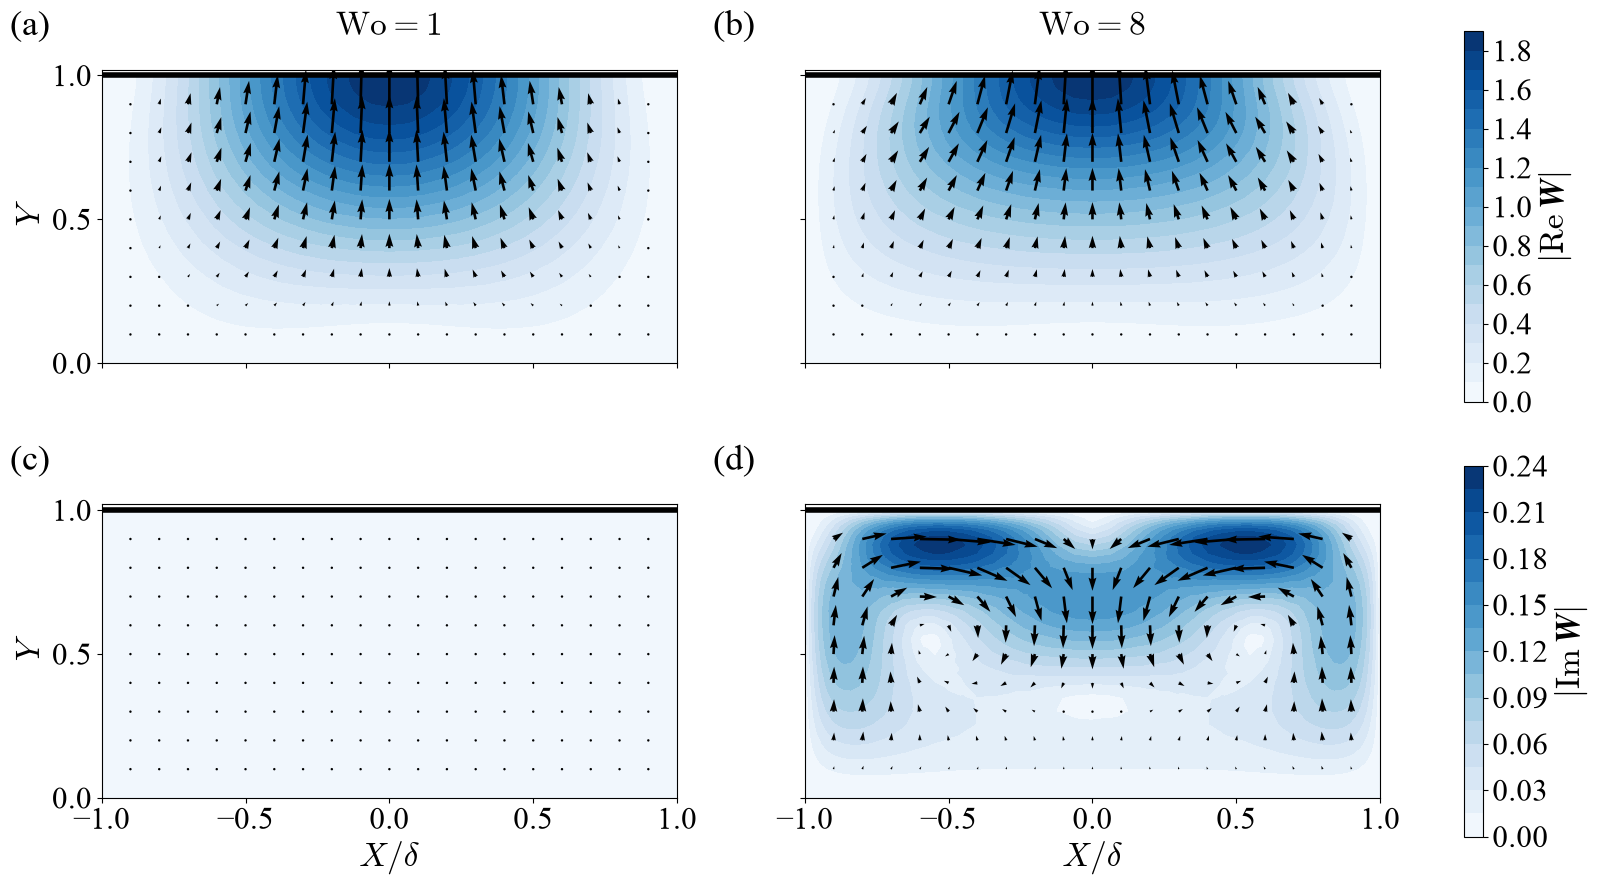

In [41]:
fs = size + 6
fig, axs = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True, layout='constrained')
part_names = [r'\mathrm{Re}', r'\mathrm{Im}']
Lx = 1/delta_field

# coarse uniform grid for the arrows
Xq, Yq = np.meshgrid(np.linspace(-Lx/2, Lx/2, 21)[1:-1], np.linspace(0, 1, 11)[1:-1])

for row, part in enumerate([np.real, np.imag]):
    # one color scale and one arrow scale per row, so that the two Wo can be compared
    vmax = 0
    for col in range(len(Wo_field)):
        vmax = max(vmax, np.max(np.hypot(part(Wx_field[col]), part(Wy_field[col]))))
    levels = ticker.MaxNLocator(20).tick_values(0, vmax)    # round values, so the colorbar ticks are round
    for col, my_Wo in enumerate(Wo_field):
        ax = axs[row, col]
        x, y = x_field[col], y_field[col]
        Wx, Wy = part(Wx_field[col]), part(Wy_field[col])
        contour = ax.tricontourf(x, y, np.hypot(Wx, Wy), levels=levels, cmap='Blues')
        Uq = griddata((x, y), Wx, (Xq, Yq))
        Vq = griddata((x, y), Wy, (Xq, Yq))
        ax.quiver(Xq, Yq, Uq, Vq, scale=vmax/0.15, scale_units='xy', color='k', zorder=2)
        # the moving top wall
        ax.plot([-Lx/2, Lx/2], [1, 1], linewidth=4, color='black')
        ax.set_aspect('equal')
        ax.set_xlim(-Lx/2, Lx/2)
        ax.set_ylim(0, 1.02)
        ax.tick_params(labelsize=fs - 2)
        if row == 0:
            ax.set_title(fr'$\mathrm{{Wo}}={my_Wo:g}$', fontsize=fs)
    axs[row, 0].set_ylabel(r'$Y$', fontsize=fs)
    cbar = fig.colorbar(contour, ax=axs[row, :], shrink=0.9)
    cbar.ax.set_ylabel(fr'$|{part_names[row]}\,\boldsymbol{{W}}|$', fontsize=fs)
    cbar.ax.tick_params(labelsize=fs - 2)
for ax in axs[1, :]:
    ax.set_xlabel(r'$X/\delta$', fontsize=fs)
# panel labels, as in theory_steady/steady_FSI_shear_thinning.ipynb
# (a) lined up with the y-label on the left and with the column titles (baseline at titlepad) at the top
trans = mtransforms.ScaledTranslation(-66/72, plt.rcParams['axes.titlepad']/72, fig.dpi_scale_trans)
axs[0, 0].text(0.0, 1.0, '(a)', fontsize=fs + 2, transform=axs[0, 0].transAxes + trans)
axs[0, 1].text(0.0, 1.0, '(b)', fontsize=fs + 2, transform=axs[0, 1].transAxes + trans)
axs[1, 0].text(0.0, 1.0, '(c)', fontsize=fs + 2, transform=axs[1, 0].transAxes + trans)
axs[1, 1].text(0.0, 1.0, '(d)', fontsize=fs + 2, transform=axs[1, 1].transAxes + trans)
plt.show()

fig.savefig('W_field_RT_delta.pdf')

## Flow-rate function $\mathfrak{f}_0(Wo,\delta)$

The real and imaginary parts of $\mathfrak{f}_0$ against $Wo$, from the closed form in the shallow limit ($\delta = 0$) and from the series for $\delta = 0.25, 0.5, 1$. Two checks: at $Wo = 0$, $\mathfrak{f}_0 = (1-\chi(\delta))/12$; and for small $\delta$, the series agrees with the closed form up to an $O(\delta)$ correction, $\mathfrak{f}_0(Wo,\delta) = \mathfrak{f}_0(Wo) - \delta\, c_1(Wo)$ with $c_1 = \sum_n 16/(n^2\pi^2\lambda_n^3)$, apart from exponentially small terms.

In [42]:
Wo_vals_f = np.linspace(1e-3, 15, 601)

# shallow limit (closed form) and the series for each delta
f0_sh = np.zeros(Wo_vals_f.size, dtype=complex)
for k, my_Wo in enumerate(Wo_vals_f):
    f0_sh[k] = F_shallow(my_Wo)[2]
f0_d = np.zeros((delta_vals.size, Wo_vals_f.size), dtype=complex)
for i, delta in enumerate(delta_vals):
    for k, my_Wo in enumerate(Wo_vals_f):
        f0_d[i, k] = f0_series(my_Wo, delta)

# check: f0(0, delta) = (1 - chi)/12
for delta in delta_vals:
    print(f'delta = {delta}:  |f0(0, delta) - (1 - chi)/12| = {abs(f0_series(0, delta) - Qhat_series(delta)):.1e}')
    assert abs(f0_series(0, delta) - Qhat_series(delta)) < 1e-12

# check: at delta = 1e-5, the series agrees with the closed form to at least 4 digits
f0_small = np.zeros(Wo_vals_f.size, dtype=complex)
for k, my_Wo in enumerate(Wo_vals_f):
    f0_small[k] = f0_series(my_Wo, 1e-5)
rel = np.max(np.abs(f0_small - f0_sh)/np.abs(f0_sh))
print(f'delta = 1e-5:  max relative difference from the closed form = {rel:.1e}')
assert rel < 1e-4

# check: the O(delta) correction, f0(Wo, delta) = f0(Wo) - delta c1(Wo)
def c1_series(Wo, nmax=20001):
    n = np.arange(1, nmax + 1, 2)
    return np.sum(16/(n**2*np.pi**2*lam(n, Wo)**3))

c1 = np.zeros(Wo_vals_f.size, dtype=complex)
for k, my_Wo in enumerate(Wo_vals_f):
    c1[k] = c1_series(my_Wo)
print(f'c1(0) = {c1_series(0).real:.5f},  (16/pi^5) sum n^-5 = {16/np.pi**5*np.sum(1.0/np.arange(1, 20002, 2)**5):.5f}')
for delta in (1e-3, 1e-2, 1e-1):
    f0_check = np.zeros(Wo_vals_f.size, dtype=complex)
    for k, my_Wo in enumerate(Wo_vals_f):
        f0_check[k] = f0_series(my_Wo, delta)
    diff = np.max(np.abs(f0_check - (f0_sh - delta*c1)))
    print(f'delta = {delta}:  max |f0(Wo, delta) - (f0(Wo) - delta c1(Wo))| = {diff:.1e}')
    assert diff < 1e-8

delta = 0.25:  |f0(0, delta) - (1 - chi)/12| = 1.7e-15
delta = 0.5:  |f0(0, delta) - (1 - chi)/12| = 1.7e-15
delta = 1.0:  |f0(0, delta) - (1 - chi)/12| = 1.8e-15


delta = 1e-5:  max relative difference from the closed form = 6.3e-06
c1(0) = 0.05252,  (16/pi^5) sum n^-5 = 0.05252


delta = 0.001:  max |f0(Wo, delta) - (f0(Wo) - delta c1(Wo))| = 2.3e-10


delta = 0.01:  max |f0(Wo, delta) - (f0(Wo) - delta c1(Wo))| = 2.3e-10


delta = 0.1:  max |f0(Wo, delta) - (f0(Wo) - delta c1(Wo))| = 2.3e-10


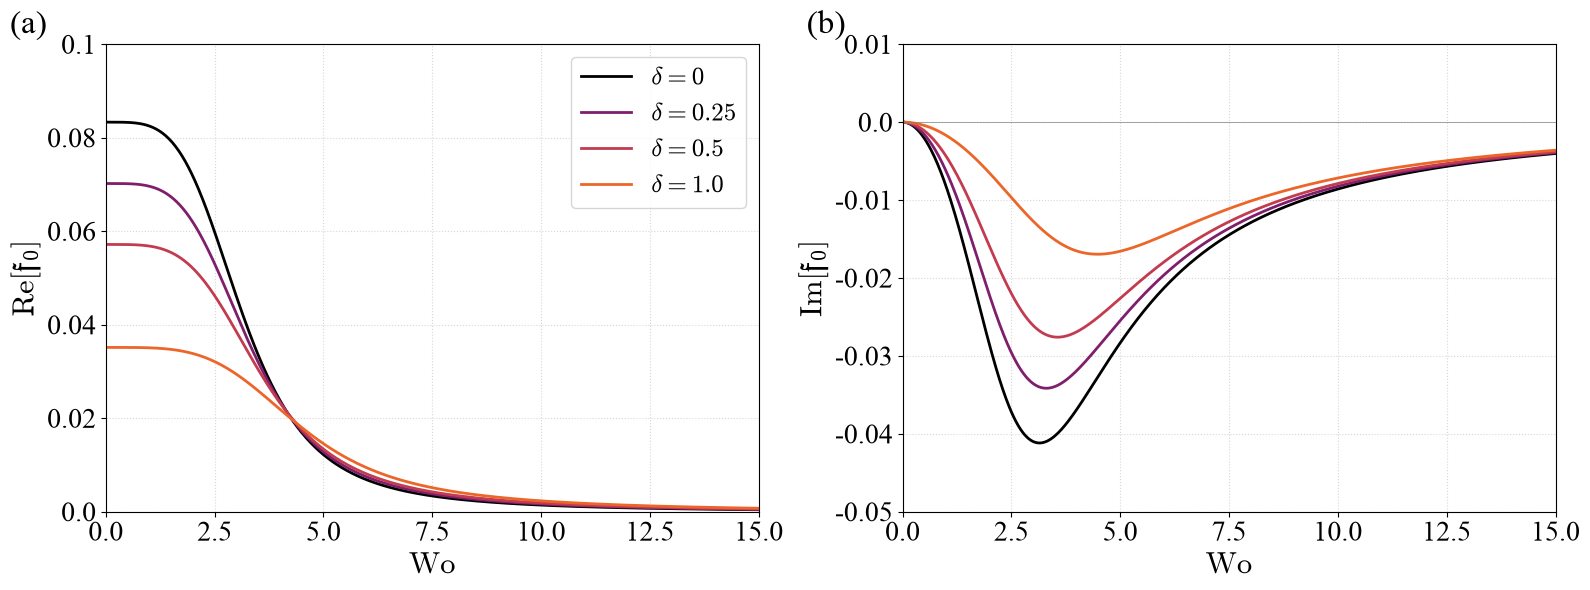

In [43]:
fs = size + 4
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharex=True, tight_layout=True)
part_labels = [r'$\mathrm{Re}[\mathfrak{f}_0]$', r'$\mathrm{Im}[\mathfrak{f}_0]$']
for col, part in enumerate([np.real, np.imag]):
    ax = axs[col]
    ax.plot(Wo_vals_f, part(f0_sh), color='k', linewidth=2, label=r'$\delta = 0$')
    for i, delta in enumerate(delta_vals):
        ax.plot(Wo_vals_f, part(f0_d[i]), color=delta_colors[i], linewidth=2, label=fr'$\delta={delta}$')
    ax.set_xlabel(r'$\mathrm{Wo}$', fontsize=fs)
    ax.set_ylabel(part_labels[col], fontsize=fs)
    ax.set_xlim(0, 15)
    ax.grid(alpha=0.5, linestyle='dotted')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.tick_params(labelsize=fs - 2)
axs[0].legend(fontsize=fs - 4)
# font hack for tick labels when using LaTeX fonts
for ax in axs:
    xticks = ax.get_xticks()
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(round(x, 4)) for x in xticks])
    yticks = ax.get_yticks()
    ax.set_yticks(yticks)
    ax.set_yticklabels([str(round(y, 4)) for y in yticks])
for ax in axs:
    ax.set_xlim(0, 15)
axs[0].set_ylim(bottom=0)
# panel labels, as in theory_steady/steady_FSI_shear_thinning.ipynb
from matplotlib import transforms as mtransforms
trans = mtransforms.ScaledTranslation(-69/72, 8/72, fig.dpi_scale_trans)    # (a) lined up with the y-label
axs[0].text(0.0, 1.0, '(a)', fontsize=fs + 2, transform=axs[0].transAxes + trans)
axs[1].text(0.0, 1.0, '(b)', fontsize=fs + 2, transform=axs[1].transAxes + trans)
plt.show()

fig.savefig('f0_vs_Wo_RT_delta.pdf')

## Wavenumber $\kappa$ of the pressure waves

The pressure $P_{0,a} = \sinh(\kappa(1-Z))/\sinh\kappa$ is a damped standing wave along the channel, with $\kappa = \kappa_r + i\kappa_i$. The peaks of $\langle Q_1 \rangle$ in the figure for arbitrary $\delta$ come through $I_1(\kappa)$, whose imaginary part is largest near $\kappa_i = m\pi$. The top row shows $\kappa_r$ (dashed) and $\kappa_i$ (solid), with grid lines at $\kappa_i = \pi, 2\pi, \ldots$; the bottom row shows $\mathrm{Im}\,I_1$. In both rows, thin vertical lines mark the $Wo$ at which $\kappa_i = m\pi$ for $\delta = 0$.

In [44]:
# kappa = sqrt(i (1+T) gamma / f0) and Im I1, from the f0 values above; arrays indexed [gamma, Wo] and [delta, gamma, Wo]
kappa_sh = np.zeros((Gm_vals_d.size, Wo_vals_f.size), dtype=complex)
kappa_d = np.zeros((delta_vals.size, Gm_vals_d.size, Wo_vals_f.size), dtype=complex)
for j, my_Gm in enumerate(Gm_vals_d):
    kappa_sh[j] = np.sqrt(1j*(1 + Tt_val_d)*my_Gm/f0_sh)
    for i in range(delta_vals.size):
        kappa_d[i, j] = np.sqrt(1j*(1 + Tt_val_d)*my_Gm/f0_d[i])
ImI1_sh = np.imag(zint_closed(kappa_sh))
ImI1_d = np.imag(zint_closed(kappa_d))

# delta = 0: Wo at which kappa_i = m pi, and Wo of the local maxima of <Q1>; lists indexed [gamma]
Wo_cross, Wo_peak = [], []
for j in range(Gm_vals_d.size):
    # crossings of kappa_i = m pi, by linear interpolation between grid points
    kappa_i = kappa_sh[j].imag
    Wo_cross.append([])
    for m in range(1, 6):
        for k in range(Wo_vals_f.size - 1):
            if kappa_i[k] < m*np.pi <= kappa_i[k+1]:
                Wo_cross[j].append(Wo_vals_f[k] + (m*np.pi - kappa_i[k])/(kappa_i[k+1] - kappa_i[k])*(Wo_vals_f[k+1] - Wo_vals_f[k]))
    # local maxima of the shallow-limit <Q1> on its grid (spacing 0.025)
    Q = Q1_sh[j]
    Wo_peak.append([Wo_vals_sh[k] for k in range(1, Q.size - 1) if Q[k] > Q[k-1] and Q[k] > Q[k+1]])

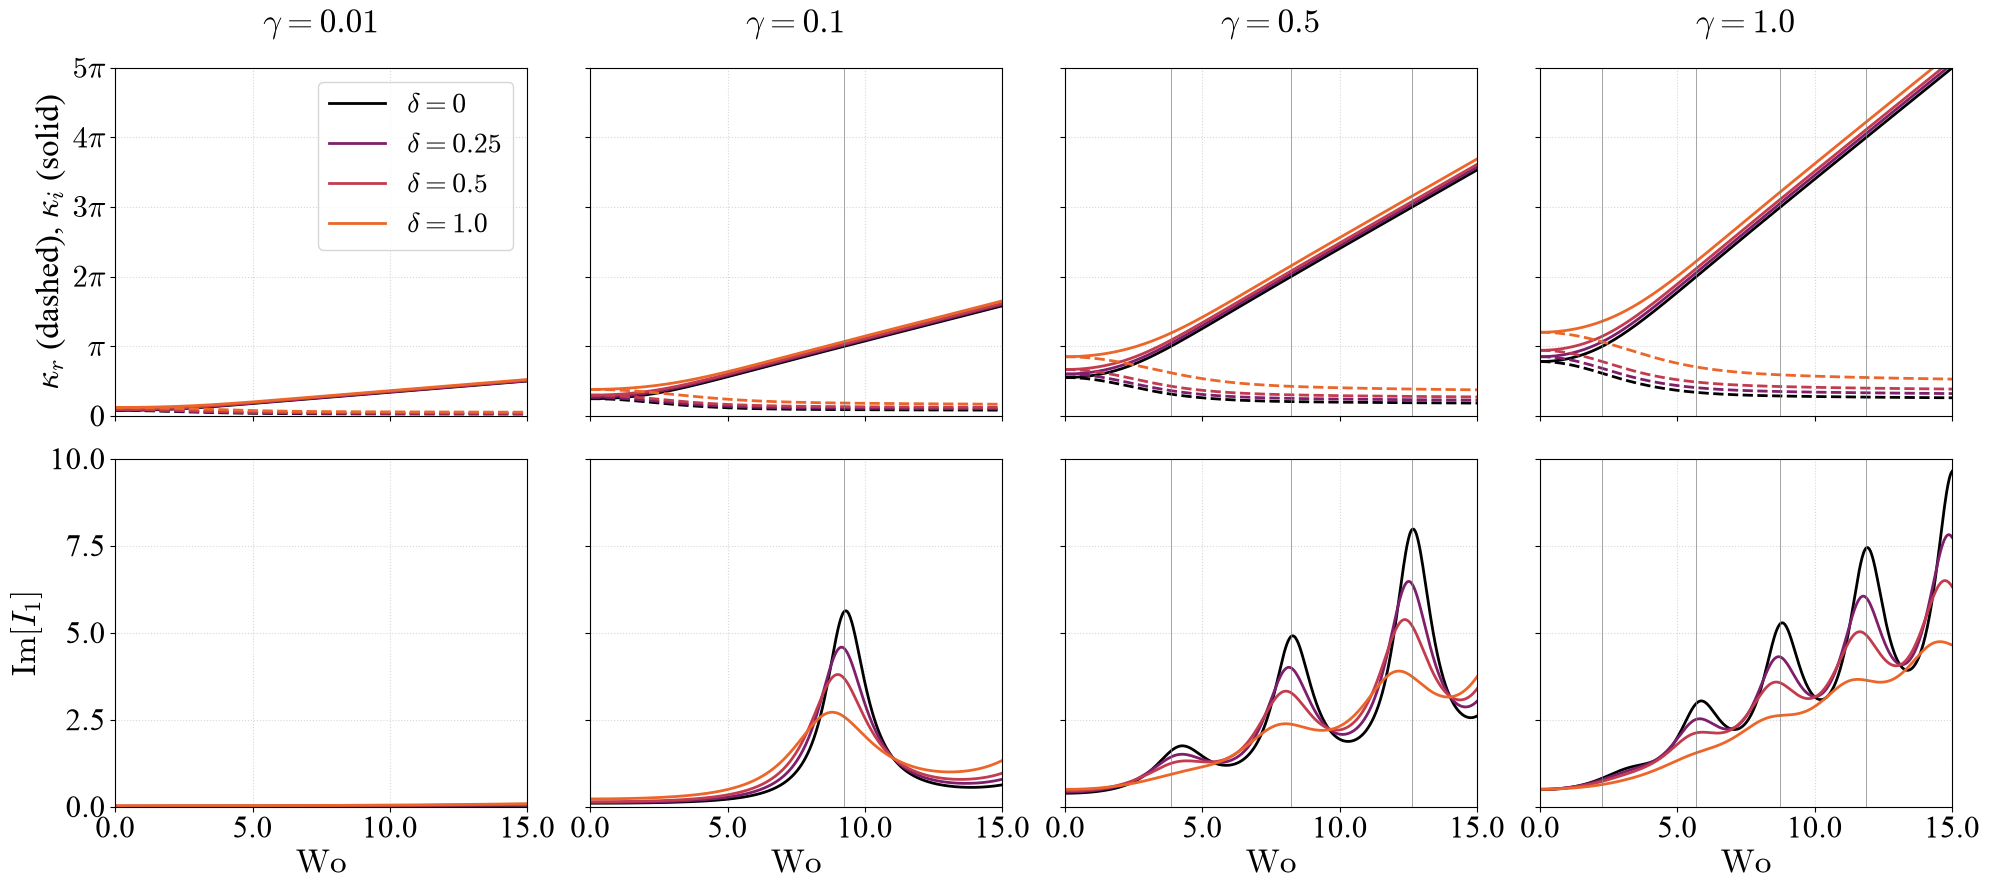

In [45]:
fs = size + 6
fig, axs = plt.subplots(2, Gm_vals_d.size, figsize=(5*Gm_vals_d.size, 9), sharex=True, sharey='row', tight_layout=True)
for j, my_Gm in enumerate(Gm_vals_d):
    ax = axs[0, j]
    ax.set_title(fr'$\gamma={my_Gm}$', fontsize=fs)
    ax.plot(Wo_vals_f, kappa_sh[j].imag, color='k', linewidth=2, label=r'$\delta = 0$')
    ax.plot(Wo_vals_f, kappa_sh[j].real, color='k', linewidth=2, linestyle='--')
    for i, delta in enumerate(delta_vals):
        ax.plot(Wo_vals_f, kappa_d[i, j].imag, color=delta_colors[i], linewidth=2, label=fr'$\delta={delta}$')
        ax.plot(Wo_vals_f, kappa_d[i, j].real, color=delta_colors[i], linewidth=2, linestyle='--')
    ax = axs[1, j]
    ax.plot(Wo_vals_f, ImI1_sh[j], color='k', linewidth=2)
    for i, delta in enumerate(delta_vals):
        ax.plot(Wo_vals_f, ImI1_d[i, j], color=delta_colors[i], linewidth=2)
    axs[1, j].set_xlabel(r'$\mathrm{Wo}$', fontsize=fs)
    # delta = 0: Wo at which kappa_i = m pi
    for ax in axs[:, j]:
        for my_Wo in Wo_cross[j]:
            ax.axvline(my_Wo, color='gray', linewidth=0.5)
axs[0, 0].set_ylabel(r'$\kappa_r$ (dashed), $\kappa_i$ (solid)', fontsize=fs)
axs[1, 0].set_ylabel(r'$\mathrm{Im}[I_1]$', fontsize=fs)
axs[0, 0].set_ylim(0, 5*np.pi)
axs[0, 0].legend(fontsize=fs - 4)
for ax in axs.flat:
    ax.set_xlim(0, 15)
    ax.grid(alpha=0.5, linestyle='dotted')
    ax.tick_params(labelsize=fs - 2)
# font hack for tick labels when using LaTeX fonts
for ax in axs.flat:
    xticks = ax.get_xticks()
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(round(x, 4)) for x in xticks])
for ax in axs[:, 0]:
    yticks = ax.get_yticks()
    ax.set_yticks(yticks)
    ax.set_yticklabels([str(round(y, 4)) for y in yticks])
for ax in axs.flat:
    ax.set_xlim(0, 15)
axs[0, 0].set_ylim(0, 5*np.pi)
axs[1, 0].set_ylim(0, 10)
# y-ticks at multiples of pi, so that the grid lines mark kappa_i = m pi
axs[0, 0].set_yticks(np.arange(6)*np.pi)
axs[0, 0].set_yticklabels(['0', r'$\pi$', r'$2\pi$', r'$3\pi$', r'$4\pi$', r'$5\pi$'])
plt.show()

fig.savefig('kappa_vs_Wo_RT_delta.pdf')

In [46]:
# delta = 0: Wo at which kappa_i = m pi, against the local maxima of <Q1> in the figure for arbitrary delta
for j, my_Gm in enumerate(Gm_vals_d):
    print(f'gamma = {my_Gm}:')
    print('    kappa_i = m pi at Wo: ' + ''.join(f'{my_Wo:7.2f}' for my_Wo in Wo_cross[j]))
    print('    <Q1> peaks at Wo:     ' + ''.join(f'{my_Wo:7.2f}' for my_Wo in Wo_peak[j]))

gamma = 0.01:
    kappa_i = m pi at Wo: 
    <Q1> peaks at Wo:        0.33
gamma = 0.1:
    kappa_i = m pi at Wo:    9.26
    <Q1> peaks at Wo:        1.00   9.23
gamma = 0.5:
    kappa_i = m pi at Wo:    3.86   8.22  12.63
    <Q1> peaks at Wo:        3.93   8.20  12.63
gamma = 1.0:
    kappa_i = m pi at Wo:    2.27   5.69   8.75  11.87
    <Q1> peaks at Wo:        3.05   5.65   8.73  11.85


# Checks on claims made in the paper

Three claims in the paper rest on derivations by hand. Here, we check each one numerically.

## Factorized form for arbitrary $\delta$

**Claim.** For any $\delta$, the streaming flow rate factorizes as
$$
    \langle Q_1 \rangle = \mathrm{Re}\big[ I_1(\kappa)\, F(Wo,\delta,\mathscr{T}) \big],
$$
where $F$ does not depend on $\gamma$, and $I_1$ has the closed form given in "Factorized form" above. Since $\mathrm{Re}[I_1] = -1/2$ exactly, this is the same as
$$
    \langle Q_1 \rangle = -\tfrac{1}{2}\mathrm{Re}[F] - \mathrm{Im}[I_1(\kappa)]\, \mathrm{Im}[F],
$$
that is, at fixed $(Wo,\delta,\mathscr{T})$, $\langle Q_1 \rangle$ is an affine function of $\mathrm{Im}[I_1]$ as $\gamma$ varies. In the shallow limit, with $(1+\mathscr{T})$ inside $F$ (see "Factorized form"),
$$
    F(Wo,0,\mathscr{T}) = (1+\mathscr{T}) \left\{ \frac{g'(1)^*}{4} - \frac{i\, Wo^2}{2 \mathfrak{f}_0} \int_0^1 \left[ 2|g|^2 \hat{V}_Z + g^* h \frac{d\hat{V}_Z}{dY} \right] dY \right\}.
$$
We check (a) the closed form of $I_1$ against quadrature; (b, c) that $F$ found from $\langle Q_1 \rangle$ at $\gamma = 0.1$ and $1$ predicts $\langle Q_1 \rangle$ at $\gamma = 0.5$, with one cross-flow solve per $(Wo,\delta)$; and (d) that, in the shallow limit, $F$ found in the same way from the symbolic RT calculation agrees with the formula above.

In [47]:
# Check 1: <Q1> = Re[I1(kappa) F(Wo, delta, T)], with F independent of gamma
def I1_quad(kappa):
    """I1 = int_0^1 P0a conj(dP0a/dZ) dZ by quadrature, for P0a = sinh(kappa (1-Z))/sinh(kappa)."""
    def integrand(Z):
        P0a = np.sinh(kappa*(1 - Z))/np.sinh(kappa)
        dP0a = -kappa*np.cosh(kappa*(1 - Z))/np.sinh(kappa)
        return P0a*np.conj(dP0a)
    return quad(integrand, 0, 1, complex_func=True, epsabs=1e-13, epsrel=1e-13)[0]

def F_from_two(Q1_a, Q1_b, ImI1_a, ImI1_b):
    """F from <Q1> = -Re[F]/2 - Im[I1] Im[F] at two values of gamma."""
    ImF = -(Q1_b - Q1_a)/(ImI1_b - ImI1_a)
    ReF = -2*(Q1_a + ImI1_a*ImF)
    return ReF + 1j*ImF

gammas = [0.1, 0.5, 1.0]
for my_Wo, delta in ((3.0, 0.5), (8.0, 0.25)):
    print(f'Wo = {my_Wo}, delta = {delta}, T = 0:')
    kappas = [kappa_delta(my_Wo, my_Gm, delta) for my_Gm in gammas]
    I1s = [zint_closed(kappa_val) for kappa_val in kappas]

    # a. closed form of I1 against quadrature
    diff_I1 = max(abs(I1z - I1_quad(kappa_val)) for I1z, kappa_val in zip(I1s, kappas))
    print(f'    a. max over gamma of |I1 closed form - quadrature| = {diff_I1:.1e}')
    assert diff_I1 < 1e-10

    # b. <Q1> at each gamma, from one cross-flow solve
    integrals = crossflow_solve(my_Wo, delta)
    Q1s = [Q1_delta(my_Wo, my_Gm, delta, integrals=integrals)['Q1'] for my_Gm in gammas]
    for my_Gm, kappa_val, I1z, Q1 in zip(gammas, kappas, I1s, Q1s):
        print(f'    b. gamma = {my_Gm}:  kappa = {kappa_val:.6f},  Im I1 = {I1z.imag:.6f},  <Q1> = {Q1:.8f}')

    # c. F from gamma = 0.1 and 1, then predict <Q1> at gamma = 0.5
    F = F_from_two(Q1s[0], Q1s[2], I1s[0].imag, I1s[2].imag)
    Q1_pred = np.real(I1s[1]*F)
    print(f'    c. F = {F:.8f};  gamma = 0.5:  predicted <Q1> = {Q1_pred:.8f},  computed {Q1s[1]:.8f},'
          f'  difference = {abs(Q1_pred - Q1s[1]):.1e}')
    assert abs(Q1_pred - Q1s[1]) < 1e-6

# d. shallow limit: F from the symbolic RT calculation (two values of gamma) against
#    F(Wo, 0, T) = F_slip + F_adv, which includes the factor 1 + T
my_Wo = 3.0
for my_Tt in (0.0, 0.3):
    Q1_sympy, ImI1 = [], []
    for my_Gm in (0.1, 1.0):
        Q1_sympy.append(quad(I1_integrand_num, 0, 1, args=(my_Wo, my_Gm, my_Tt))[0]
                        + dblquad(RT_integrand_num, 0, 1, 0, 1, args=(my_Wo, my_Gm, my_Tt))[0])
        ImI1.append(zint_closed(np.sqrt(1j*(1 + my_Tt)*my_Gm/F_shallow(my_Wo)[2])).imag)
    F_RT = F_from_two(*Q1_sympy, *ImI1)
    F_slip, F_adv, _ = F_shallow(my_Wo, my_Tt)
    F_new = F_slip + F_adv
    print(f'd. Wo = {my_Wo}, T = {my_Tt}:  F from symbolic RT = {F_RT:.8f},  F_slip + F_adv = {F_new:.8f},'
          f'  difference = {abs(F_RT - F_new):.1e}')
    assert abs(F_RT - F_new) < 1e-6

Wo = 3.0, delta = 0.5, T = 0:
    a. max over gamma of |I1 closed form - quadrature| = 3.5e-16


    b. gamma = 0.1:  kappa = 0.686928+1.295582j,  Im I1 = 0.185507,  <Q1> = 0.03596702
    b. gamma = 0.5:  kappa = 1.536018+2.897010j,  Im I1 = 0.928763,  <Q1> = 0.08543684
    b. gamma = 1.0:  kappa = 2.172257+4.096991j,  Im I1 = 0.901577,  <Q1> = 0.08362739
    c. F = -0.04724001-0.06655826j;  gamma = 0.5:  predicted <Q1> = 0.08543684,  computed 0.08543684,  difference = 0.0e+00
Wo = 8.0, delta = 0.25, T = 0:
    a. max over gamma of |I1 closed form - quadrature| = 9.0e-16


    b. gamma = 0.1:  kappa = 0.354115+2.795568j,  Im I1 = 2.070048,  <Q1> = 0.04346106
    b. gamma = 0.5:  kappa = 0.791825+6.251080j,  Im I1 = 3.941897,  <Q1> = 0.10177859
    b. gamma = 1.0:  kappa = 1.119810+8.840363j,  Im I1 = 3.386876,  <Q1> = 0.08448689
    c. F = 0.04206273-0.03115504j;  gamma = 0.5:  predicted <Q1> = 0.10177859,  computed 0.10177859,  difference = 2.8e-17
d. Wo = 3.0, T = 0.0:  F from symbolic RT = -0.04270887-0.09093110j,  F_slip + F_adv = -0.04270887-0.09093110j,  difference = 1.8e-10


d. Wo = 3.0, T = 0.3:  F from symbolic RT = -0.05552153-0.11821043j,  F_slip + F_adv = -0.05552153-0.11821043j,  difference = 2.3e-10


## Primary pressure under flow-rate control

**Claim.** If the inlet flow rate is imposed, $Q_{0,a} = -\mathfrak{f}_0\, dP_{0,a}/dZ = 1$ at $Z = 0$, instead of the inlet pressure, then the primary pressure is $C\, \sinh\big(\kappa(1-Z)\big)/\sinh\kappa$, with
$$
    C = \frac{\tanh\kappa}{\kappa\, \mathfrak{f}_0(Wo,\delta)},
$$
and $C = P_{0,a}(0) - P_{0,a}(1)$ is the amplitude of the primary pressure drop. We solve $d^2P/dZ^2 = \kappa^2 P$ with $-\mathfrak{f}_0\, dP/dZ = 1$ at $Z = 0$ and $P = 0$ at $Z = 1$, by linear algebra on the two exponentials $e^{\pm\kappa Z}$, and compare. In the shallow, low-frequency limit, $\mathfrak{f}_0 \to 1/12$ and $\kappa \to 0$, so $C \to 12$.

In [48]:
# Check 2: flow-rate control, P0a = C sinh(kappa (1-Z))/sinh(kappa) with C = tanh(kappa)/(kappa f0)
def P_flow_control(kappa, f0, Z):
    """Solution of P'' = kappa^2 P with -f0 P'(0) = 1 and P(1) = 0, as a exp(kappa Z) + b exp(-kappa Z)."""
    M = np.array([[-f0*kappa, f0*kappa],                 # -f0 P'(0) = 1
                  [np.exp(kappa), np.exp(-kappa)]])      # P(1) = 0
    a, b = np.linalg.solve(M, np.array([1, 0], dtype=complex))
    return a*np.exp(kappa*Z) + b*np.exp(-kappa*Z)

Zs = np.linspace(0, 1, 201)
points = [[3.0, 0.5, 0.5, 0.0],
          [8.0, 1.0, 0.25, 0.3],
          [12.0, 0.1, 1.0, 0.0]]
for my_Wo, my_Gm, delta, my_Tt in points:
    f0_val = f0_series(my_Wo, delta)
    kappa_val = kappa_delta(my_Wo, my_Gm, delta, my_Tt)
    C = np.tanh(kappa_val)/(kappa_val*f0_val)
    P = P_flow_control(kappa_val, f0_val, Zs)
    diff = np.max(abs(P - C*np.sinh(kappa_val*(1 - Zs))/np.sinh(kappa_val)))
    print(f'Wo = {my_Wo}, gamma = {my_Gm}, delta = {delta}, T = {my_Tt}:  C = {C:.8f},  P(0) = {P[0]:.8f},'
          f'  max |P - C P0a| = {diff:.1e},  |P(0) - C| = {abs(P[0] - C):.1e}')
    assert diff < 1e-8 and abs(P[0] - C) < 1e-8

# low-frequency limit in the shallow limit: C -> 1/f0 = 12
my_Wo, my_Gm = 1e-3, 1e-6
f0_val = F_shallow(my_Wo)[2]
kappa_val = np.sqrt(1j*my_Gm/f0_val)
C = np.tanh(kappa_val)/(kappa_val*f0_val)
print(f'delta -> 0, Wo = {my_Wo}, gamma = {my_Gm}:  C = {C:.8f},  |C - 12| = {abs(C - 12):.1e}')
assert abs(C - 12) < 1e-3

Wo = 3.0, gamma = 0.5, delta = 0.5, T = 0.0:  C = 5.21050122-3.06079255j,  P(0) = 5.21050122-3.06079255j,  max |P - C P0a| = 3.0e-15,  |P(0) - C| = 8.9e-16
Wo = 8.0, gamma = 1.0, delta = 0.25, T = 0.3:  C = 7.50708104+0.18101721j,  P(0) = 7.50708104+0.18101721j,  max |P - C P0a| = 9.2e-15,  |P(0) - C| = 3.6e-15
Wo = 12.0, gamma = 0.1, delta = 1.0, T = 0.0:  C = 55.90955043+25.34840388j,  P(0) = 55.90955043+25.34840388j,  max |P - C P0a| = 3.8e-14,  |P(0) - C| = 1.0e-14
delta -> 0, Wo = 0.001, gamma = 1e-06:  C = 11.99999999-0.00004683j,  |C - 12| = 4.7e-05


## Run time

**Claim.** All the data in the figure for arbitrary $\delta$ (in "Streaming flow rate against $Wo$") were generated in under an hour on a laptop. We time their generation from scratch, in a temporary folder, so that the saved results are neither used nor changed, and check the new values against the saved ones. To keep this notebook quick to run, the cell below times every 15th $Wo$ and extrapolates; set `time_full_sweep = True` to time the whole sweep. With `time_full_sweep = True`, the whole sweep (453 cross-flow solves) took 15 min on an Apple M3 laptop (8 cores, 16 GB, one MPI process), on 2 October 2026. The time per solve varies with the load on the machine, so the extrapolated time printed below varies from run to run (8 and 14 min in two runs).

In [49]:
# Check 3: wall time to generate the data for the figure for arbitrary delta from scratch,
# in a temporary folder, so that the saved results in cache_3D/ are not used or changed
import tempfile, time, platform

time_full_sweep = False    # True: the whole sweep; False: every 15th Wo, then extrapolate to the whole sweep
k_sub = np.arange(Wo_vals_d.size) if time_full_sweep else np.arange(0, Wo_vals_d.size, 15)

print(f'machine: {platform.machine()}, {platform.platform()}, {os.cpu_count()} cores, one MPI process')
print(f'mesh: Taylor-Hood Q2/Q1, ny = 32 cells across the depth;  nx = '
      + ', '.join(f'{crossflow_mesh(delta, 32).topology.index_map(2).size_local//32} (delta = {delta:g})' for delta in delta_vals))

# shallow limit (closed form), as in the figure
t0 = time.perf_counter()
for my_Gm in Gm_vals_d:
    for my_Wo in Wo_vals_sh:
        Q1_shallow(my_Wo, my_Gm, Tt_val_d)
t_sh = time.perf_counter() - t0
print(f'shallow limit: {Gm_vals_d.size*Wo_vals_sh.size} closed-form evaluations in {t_sh:.1f} s')

# arbitrary delta: one cross-flow solve per (Wo, delta), checked against the saved results
t_d = 0.0
with tempfile.TemporaryDirectory() as tmp_dir:
    for i, delta in enumerate(delta_vals):
        t0 = time.perf_counter()
        if time_full_sweep:
            data = load_or_compute(f'{tmp_dir}/Q1_vs_Wo_delta{delta:g}_3D.npz', lambda: compute_Q1_delta_of_Wo(delta))
            Q1 = data['Q1']
        else:
            Q1 = np.zeros((Gm_vals_d.size, k_sub.size))
            for kk, k in enumerate(k_sub):
                integrals = crossflow_solve(Wo_vals_d[k], delta, Tt_val_d)
                for j, my_Gm in enumerate(Gm_vals_d):
                    Q1[j, kk] = Q1_delta(Wo_vals_d[k], my_Gm, delta, Tt_val_d, integrals=integrals)['Q1']
        t = time.perf_counter() - t0
        t_d += t
        diff = np.max(abs(Q1 - Q1_d[i][:, k_sub]))
        print(f'delta = {delta:g}: {k_sub.size} solves in {t:.1f} s ({t/k_sub.size:.2f} s per solve),'
              f'  max |<Q1> - saved| = {diff:.1e}')
        assert diff < 1e-12

n_solves = delta_vals.size*Wo_vals_d.size
if time_full_sweep:
    print(f'whole sweep: {n_solves} solves;  wall time {(t_sh + t_d)/60:.1f} min')
else:
    t_est = t_sh + t_d*Wo_vals_d.size/k_sub.size
    print(f'whole sweep: {n_solves} solves;  wall time extrapolated from {delta_vals.size*k_sub.size} solves: {t_est/60:.1f} min')

machine: arm64, macOS-27.0-arm64-arm-64bit, 8 cores, one MPI process
mesh: Taylor-Hood Q2/Q1, ny = 32 cells across the depth;  nx = 96 (delta = 0.25), 64 (delta = 0.5), 32 (delta = 1)


shallow limit: 2404 closed-form evaluations in 3.6 s


delta = 0.25: 11 solves in 22.8 s (2.07 s per solve),  max |<Q1> - saved| = 2.8e-17


delta = 0.5: 11 solves in 25.8 s (2.35 s per solve),  max |<Q1> - saved| = 2.1e-17


delta = 1: 11 solves in 9.4 s (0.85 s per solve),  max |<Q1> - saved| = 6.9e-18
whole sweep: 453 solves;  wall time extrapolated from 33 solves: 13.3 min


# References

*   [PBC26a] S. D. Pande, E. Boyko, I. C. Christov, Reciprocal theorem for calculating the flow rate of oscillatory channel flows, _Mech. Res. Commun._ **151** (2026) 104589. [doi:10.1016/j.mechrescom.2025.104589](https://doi.org/10.1016/j.mechrescom.2025.104589); [arXiv:2312.10183](https://arxiv.org/abs/2312.10183)

*   [PBC26b] S. D. Pande, E. Boyko, I. C. Christov, The rectified flow rate of an oscillatory flow in a weakly deformable three-dimensional channel via the reciprocal theorem, in preparation.

*   [RPC26] U. M. Rade, S. D. Pande, I. C. Christov, Theory and simulation of elastoinertial rectification of oscillatory flows in two-dimensional deformable rectangular channels, _Phys. Rev. Fluids_ **11** (2026) 074102. [doi:10.1103/zk9v-13sn](https://doi.org/10.1103/zk9v-13sn); [arXiv:2505.22799](https://arxiv.org/abs/2505.22799)

*   [ZR24] X. Zhang, B. Rallabandi, Elasto-inertial rectification of oscillatory flow in an elastic tube, _J. Fluid Mech._ **996** (2024) A16. [doi:10.1017/jfm.2024.612](https://doi.org/10.1017/jfm.2024.612); [arXiv:2404.02292](https://arxiv.org/abs/2404.02292)